# Deep Learning พื้นฐาน Neuron To DenseNet


---

macOS ตัวจัดการ thread (OpenMP) ของ PyTorch กับของ XGBoost ชนกัน
ถ้าไม่ตั้งค่านี้ไว้ก่อน import ทั้งสองตัว เซลล์ที่เรียก XGBoost จะทำให้ kernel dead


In [113]:
import os
import platform

if platform.system() == 'Darwin':          # เฉพาะ macOS
    os.environ.setdefault('OMP_NUM_THREADS', '1')

print('Ready Operation system:', platform.system())

Ready Operation system: Darwin


In [114]:
! unzip /content/img_jupyter.zip -d /content/

unzip:  cannot find or open /content/img_jupyter.zip, /content/img_jupyter.zip.zip or /content/img_jupyter.zip.ZIP.


---

<a id="teaser"></a>

## Neural Network กับ Titanic Data set

Neural network ที่ใช้ข้อมูลของ Titanic ที่ clean แล้วเข้าไปเพื่อทำการ Train model โดยจะไม่ทำ Feature Engineering หรือจัดการ Feature ต่างๆ เพื่อให้ Model ลองเรียนรู้เอง (Clean data อย่างเดียว)


In [115]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

# --- โหลด Titanic แล้ว clean แบบเดียวกับที่ทำในสัปดาห์ที่ 3 ---
try:
    df = sns.load_dataset('titanic')

except Exception:  # สำรองถ้าโหลดจาก seaborn ไม่ได้
    from sklearn.datasets import fetch_openml
    raw = fetch_openml('titanic', version=1, as_frame=True).frame
    df = pd.DataFrame({
        'survived': raw['survived'].astype(int),
        'pclass': raw['pclass'].astype(int),
        'sex': raw['sex'],
        'age': pd.to_numeric(raw['age'], errors='coerce'),
        'sibsp': pd.to_numeric(raw['sibsp'], errors='coerce'),
        'parch': pd.to_numeric(raw['parch'], errors='coerce'),
        'fare': pd.to_numeric(raw['fare'], errors='coerce'),
    })

cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']
data = df[cols + ['survived']].copy()
data['age'] = data['age'].fillna(data['age'].median())
data['fare'] = data['fare'].fillna(data['fare'].median())
data['sex'] = (data['sex'] == 'male').astype(int)

X = data[cols].to_numpy(dtype='float32')
y = data['survived'].to_numpy(dtype='float32')


X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler().fit(X_tr)

X_tr = torch.tensor(scaler.transform(X_tr), dtype=torch.float32) # แปลงเป็น Tensor สำหรับ X_train
X_te = torch.tensor(scaler.transform(X_te), dtype=torch.float32)  # แปลงเป็น Tensor สำหรับ X_test

print('Target shape before reshape')
print('shape', y_tr.shape , '\n') # dimension 1 
#print(y_tr)

y_tr = torch.tensor(y_tr).unsqueeze(1) # Reshape to tensor (2x1) dimension

print('Target shape after reshape')
print('shape', y_tr.shape , '\n')
#print(y_tr)

y_te = torch.tensor(y_te).unsqueeze(1)
print('Dataset shape train set:', tuple(X_tr.shape), 'test set shape:', tuple(X_te.shape))

Target shape before reshape
shape (712,) 

Target shape after reshape
shape torch.Size([712, 1]) 

Dataset shape train set: (712, 6) test set shape: (179, 6)


In [116]:
# วาดรูป 
# ===== Neural Network =====
model = nn.Sequential(nn.Linear(6, 16),   # (input, output) 
                    nn.ReLU(), 
                    nn.Linear(16, 1)) # Input จำนวน 6 node 1 hidden layer 16 node 1   node output




loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(300):
    optimizer.zero_grad()
    loss = loss_fn(model(X_tr), y_tr)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    acc = ((model(X_te) > 0).float() == y_te).float().mean()
print(f'accuracy บน test set = {acc.item():.1%}')

accuracy บน test set = 79.3%


Model ทำความแม่นยำได้ประมาณ 78 ถึง 82 เปอร์เซ็นต์ โดยที่เราไม่ได้ทำ Feature engineer เลย
ไม่ได้บอกว่าผู้หญิงรอดเยอะกว่า ไม่ได้บอกว่าชั้นหนึ่งรอดเยอะกว่า มันหาเอาเองจากข้อมูล

**คำถาม**

1. Model มี Architecture อย่างไร
2. NN ดีกว่า Random Forest ที่เรียนไปสัปดาห์ก่อนจริงหรือเปล่า


In [117]:
# ล้าง Gradient ของ Model ไม่ให้ค้างใน GPU memory
del model, optimizer, loss_fn
if torch.cuda.is_available():
    torch.cuda.empty_cache()

---

<a id="sec1"></a>

# Step 1 Data 2 D

Plot เส้นแบ่ง (decision boundary) ออกมาดูได้ตรงๆ ว่าโมเดลมีขั้นตอนการคิดอย่างไร

## เตรียมเครื่องมือ


In [118]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import make_moons

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# device-agnostic: ใช้ GPU ถ้ามี ไม่มีก็ CPU รันได้เหมือนกันทั้ง Colab T4 และ RTX 4070
DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('device =', DEVICE)

IMG = Path('images')          # เก็บ Path ของรูป เพื่อนำรูปมาทำรายงาน 
IMG.mkdir(exist_ok=True)  # สร้าง Folder

# ข้อมูล 500 จุด 2 feature
X_np, y_np = make_moons(n_samples=500, noise=0.2, random_state=SEED)
X = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
y = torch.tensor(y_np, dtype=torch.float32, device=DEVICE).unsqueeze(1)
print('X', tuple(X.shape), ' y', tuple(y.shape))

device = mps
X (500, 2)  y (500, 1)


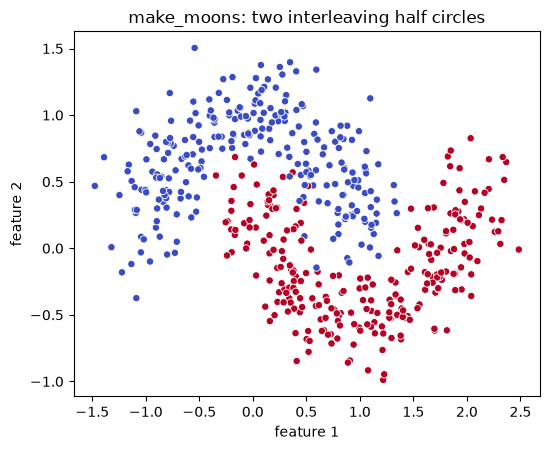

In [119]:
def plot_boundary(model, title, save_as=None):
    pad = 0.5
    xx, yy = np.meshgrid(
        np.linspace(X_np[:, 0].min() - pad, X_np[:, 0].max() + pad, 300),
        np.linspace(X_np[:, 1].min() - pad, X_np[:, 1].max() + pad, 300),
    )
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        zz = (model(grid) > 0).float().cpu().numpy().reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(5.6, 4.6))
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], colors=['#bfdbfe', '#fed7aa'])
    ax.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='coolwarm',
               edgecolor='white', linewidth=0.6, s=28)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('feature 1')
    ax.set_ylabel('feature 2')
    fig.tight_layout()
    if save_as:
        fig.savefig(IMG / save_as, dpi=150)
    plt.show()


fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='coolwarm',
           edgecolor='white', linewidth=0.6, s=28)
ax.set_title('make_moons: two interleaving half circles', fontsize=12)
ax.set_xlabel('feature 1')
ax.set_ylabel('feature 2')
fig.tight_layout()
fig.savefig(IMG / 'out_1_0_data.png', dpi=150)  # Save ภาพ
plt.show()

**รูปที่ 1** ข้อมูล make_moons ต้องใช้เส้นโค้งถึงจะแยกได้
คำถามคือโมเดลจะสามารถหาเส้นโค้งเพื่อมา Fit กับ Data ได้ไหม

---

## 1.1 Tensor และ Autograd

**Tensor** คือ array ตัวเลขแบบเดียวกับ numpy แต่มีความสามารถพิเศษเพิ่มมาสองข้อ
หนึ่งคือย้ายไปคำนวณบน GPU ได้ สองคือจำได้ว่าตัวเองถูกคำนวณมาจากอะไรบ้าง

**Autograd** คือความสามารถจากข้อที่สอง ถ้าเราบอกว่า tensor ตัวไหน `requires_grad=True`
PyTorch จะจด log ทุกขั้นตอนที่ tensor ตัวนั้นไปเกี่ยวข้อง แล้วตอนเรียก `.backward()`
มันจะย้อนกลับไปคำนวณอนุพันธ์ให้ครบทุกตัวโดยอัตโนมัติ


In [120]:
# tensor ธรรมดา ทำตัวเหมือน numpy
a = torch.tensor([1.0, 2.0, 3.0])
print('a       =', a)
print('a * 2   =', a * 2)
print('a.mean()=', a.mean().item())

# tensor ที่ใช้จด Log
w_one = torch.tensor(3.0, requires_grad=True)
L_one = w_one ** 2         # PyTorch จดไว้ว่า L มาจาก w ยกกำลังสอง
L_one.backward()           # ย้อนกลับไปคำนวณอนุพันธ์

print('w_one:',w_one )
print('L_one:', L_one, '\n')

# # Dift (Cal slope)
print('L = w**2 ที่ w=3 ได้ L =', L_one.item(), 'w**2 = w^2 = 3^2\n')
print('dL/dw ที่ PyTorch Cal =', w_one.grad.item(), ' (Calculate 2w = 6)')

a       = tensor([1., 2., 3.])
a * 2   = tensor([2., 4., 6.])
a.mean()= 2.0
w_one: tensor(3., requires_grad=True)
L_one: tensor(9., grad_fn=<PowBackward0>) 

L = w**2 ที่ w=3 ได้ L = 9.0 w**2 = w^2 = 3^2

dL/dw ที่ PyTorch Cal = 6.0  (Calculate 2w = 6)


<img src="https://raw.githubusercontent.com/vasuprint/AI-CE564/main/weeks/W05_neuralnetwork/img_jupyter/fig03_chainrule.png" width="640">

**รูปที่ 2** กราฟการคำนวณของตัวอย่างข้างล่าง ขาไปคือ forward ขากลับคือ backward
ตัว `.backward()` มีการคำนวณดังสมการ ที่แนบด้านล่าง

ตรงนี้คือ **backpropagation** ใช้กฎลูกโซ่ (chain rule)
ที่เรียนในแคลคูลัส แค่ทำซ้ำย้อนจากปลายกลับมาต้นทางทีละขั้น

ลองพิสูจน์ให้เห็นกับตาว่าเลขที่ `.backward()` คำนวณ ตรงกับที่เราหาด้วยมือจริง
ใช้ฟังก์ชันง่ายที่สุดคือ $y = wx$ แล้ว $L = (y - t)^2$ ซึ่งหาอนุพันธ์ได้จากการคำนวณ

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial w} = 2(y - t) \cdot x$$


In [121]:
# ===== พิสูจน์ว่า autograd ให้เลขเดียวกับที่คำนวณได้ =====
x_demo = torch.tensor(2.0)                      # input
t_demo = torch.tensor(1.0)                      # ค่าที่ถูกต้อง (target)
w_demo = torch.tensor(3.0, requires_grad=True)  # น้ำหนักที่ต้องเรียน

y_demo = w_demo * x_demo                        # forward ขั้นที่ 1
L_demo = (y_demo - t_demo) ** 2                 # forward ขั้นที่ 2 คือ loss
L_demo.backward()                               # backward

by_hand = 2 * (y_demo.item() - t_demo.item()) * x_demo.item()
print(f'y = w*x        = {y_demo.item():.1f}')
print(f'L = (y-t)^2    = {L_demo.item():.1f}')
print()
print(f'Self chain rule:  2(y-t)x = {by_hand:.1f}')
print(f'autograd   w.grad  = {w_demo.grad.item():.1f}')
print('Matching ?:', abs(by_hand - w_demo.grad.item()) < 1e-6)

y = w*x        = 6.0
L = (y-t)^2    = 25.0

Self chain rule:  2(y-t)x = 20.0
autograd   w.grad  = 20.0
Matching ?: True


ตรงกัน นี่คือเหตุผลที่ไม่ต้องคำนวณ gradient ด้วยตนเองหรือเขียนโปรแกรมเอง
แม้ว่า Model จะมี weight อีก หลาย ล้าน พารามิเตอร์ `.backward()` ก็ทำแบบเดียวกันนี้ให้ครบทุกตัว

> **หมายเหตุ** ในโมเดลจริงเราปล่อยให้ autograd ทำงานทั้งหมด ไม่ต้องทำการคำนวณเองหรือเขียน Function เพิ่มเติม

---

## 1.2 ทดสอบด้วย Logistic regression

เริ่มจากโมเดลที่ง่ายที่สุดคือ `nn.Linear` ชั้นเดียว

**นี่คือ logistic regression ที่เรียนไปสัปดาห์ก่อน**
แค่เขียนด้วย PyTorch แทน scikit-learn เพื่อให้เห็นวิธีการ

โครงการเขียน `nn.Module` มีสองส่วนเสมอ
`__init__` ประกาศว่ามีชั้นอะไรบ้าง และ `forward` บอกว่าข้อมูลไหลผ่านชั้นพวกนั้นตามลำดับไหน


In [122]:
# ===== 1.2 โมเดลเส้นตรง (logistic regression PyTorch) =====
class LinearNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 1)       # Input 2 feature Output 1 

    def forward(self, x):
        return self.fc1(x)              


torch.manual_seed(SEED)      # สุ่ม weight 
model = LinearNet().to(DEVICE)
loss_fn = nn.BCEWithLogitsLoss()      # sigmoid คือสมการเดียวกับ BCE
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

print(model)
print('จำนวนพารามิเตอร์ที่ต้อง Train :', sum(p.numel() for p in model.parameters()))

LinearNet(
  (fc1): Linear(in_features=2, out_features=1, bias=True)
)
จำนวนพารามิเตอร์ที่ต้อง Train : 3


**ทำไมไม่มี sigmoid ในโมเดล** เพราะ `BCEWithLogitsLoss` มี sigmoid อยู่ข้างใน
โดยค่าจะ "ผ่าน sigmoid แล้วได้ความน่าจะเป็น" เหมือนเดิม แค่ PyTorch รวมขั้นนั้นเข้าไปใน loss
เพื่อความเสถียรของการคำนวณ ถ้าเราใส่ sigmoid เองด้วยจะกลายเป็นใส่ซ้ำสองรอบ แล้วโมเดลจะไม่เรียน
จึงเป็นข้อควรระวัง สำหรับ BCE ที่ Layer output

<img src="https://raw.githubusercontent.com/vasuprint/AI-CE564/main/weeks/W05_neuralnetwork/img_jupyter/fig02_loop5.png" width="820">

**รูปที่ 3** ห้าขั้นตอนของการเทรน วนซ้ำแบบนี้ไปเรื่อยๆ จนกว่า loss จะไม่ลดลงหรือได้ค่า Accuracy ตามที่ต้องการ


In [123]:
# ===== training loop 5 ขั้นตอน =====
EPOCHS = 300      #จำนวนรอบการ Train
losses_linear = []  # สร้าง Array เก็บค่า เพื่อ plot graph

for epoch in range(EPOCHS):        # คำนวณ สร้าง Computation graph เก็บ Activation แต่ละ Layer และ รอทำ backward
    optimizer.zero_grad()          # 1 ล้าง gradient เก่าทิ้ง
    pred = model(X)                # 2 forward ป้อนข้อมูลเข้าโมเดล
    loss = loss_fn(pred, y)        # 3 วัดว่าทายผิดไปเท่าไร
    loss.backward()                # 4 backprop หาว่าน้ำหนักแต่ละตัวควรขยับทางไหน
    optimizer.step()               # 5 ปรับweight

    losses_linear.append(loss.item())
    if (epoch + 1) % 60 == 0:
        print(f'epoch {epoch + 1:4d}  loss = {loss.item():.4f}')

with torch.no_grad(): #เป็นการบอก model ว่าจะนำ Model ไป Inference ไม่ต้องทำการบันทึก log ช่วยประหยัด Ram และไวขึ้น
    acc_linear = 1-loss.item()
print(f'\naccuracy = {acc_linear:.1%}')

epoch   60  loss = 0.2951
epoch  120  loss = 0.2809
epoch  180  loss = 0.2798
epoch  240  loss = 0.2797
epoch  300  loss = 0.2797

accuracy = 72.0%


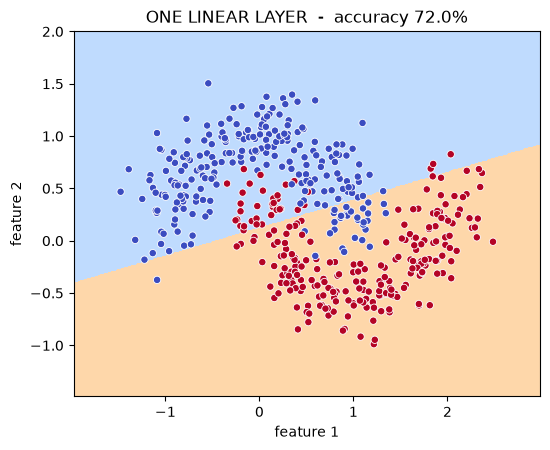

In [124]:
plot_boundary(model, f'ONE LINEAR LAYER  -  accuracy {acc_linear:.1%}',
              save_as='out_1_2_linear_boundary.png')

**รูปที่ 4** เส้นแบ่งของโมเดลเส้นตรง ได้ความแม่นราว 86 เปอร์เซ็นต์

ดูรูปแล้วเห็นชัดว่า **เส้นแบ่งเป็นเส้นตรง** มันพยายามเต็มที่แล้ว
แต่จะลากเส้นตรงยังไงก็แยกพระจันทร์สองเสี้ยวที่สอดกันไม่ออก
ตรงรอยต่อจะกินเข้าไปในฝั่งตรงข้ามเสมอ

**คำถาม** ทำไมมันวาดได้แค่เส้นตรง และจะทำยังไงให้มันวาดเส้นโค้งได้

---

## 1.3 เพิ่ม activation ใน Hidden Layer

เฉลยข้อแรก `nn.Linear` คือการคูณเมทริกซ์แล้วบวก bias ซึ่งโดยนิยามคือฟังก์ชันเชิงเส้น
มันวาดได้แค่เส้นตรงหรือระนาบแบน (เส้นตรง)

**ข้อควรระวัง** คนมักคิดว่า "เพิ่ม Linear หลายๆ Layer" ซึ่งไม่ช่วยเลย
เพราะ Linear ซ้อน Linear โดยไม่มีอะไรคั่น จะยุบกลับเป็น Linear ชั้นเดียวเสมอ

<img src="https://raw.githubusercontent.com/vasuprint/AI-CE564/main/weeks/W05_neuralnetwork/img_jupyter/fig04_collapse.png" width="880">

**รูปที่ 5** ซ้ายคือซ้อนเฉยๆ ซึ่งยุบกลับเป็นชั้นเดียว ขวาคือมี ReLU คั่น ซึ่งยุบไม่ได้

ลองพิสูจน์ด้วยโค้ดว่าจริงตาม ทฏษฐีไหม?


พารามิเตอร์เพิ่มเป็น 65 ตัว
accuracy = 86.0%   (ชั้นเดียวได้ 72.0%)


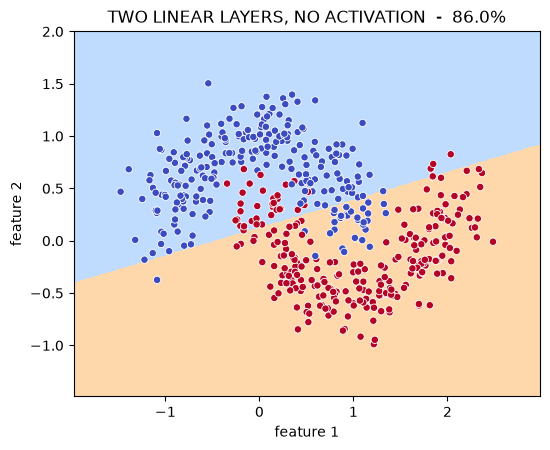

In [125]:
# ===== พิสูจน์ Linear ซ้อน Linear ที่ไม่มี activation คั่น =====

# 1. Create model
class StackedLinearNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 16) # มีกี่ Input ? 2 Input F1, F2
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.fc1(x)          # ไม่มี activation  คั่นระหว่าง layer 
        x = self.fc2(x)
        return x

# 2. Init loss, optimize
torch.manual_seed(SEED)
model_stacked = StackedLinearNet().to(DEVICE)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_stacked.parameters(), lr=0.1)

# 3. Train model
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    loss = loss_fn(model_stacked(X), y)
    loss.backward()
    optimizer.step()

# 4. Evaluate 
with torch.no_grad():
    acc_stacked = ((model_stacked(X) > 0).float() == y).float().mean().item()
print(f'พารามิเตอร์เพิ่มเป็น {sum(p.numel() for p in model_stacked.parameters())} ตัว')
print(f'accuracy = {acc_stacked:.1%}   (ชั้นเดียวได้ {acc_linear:.1%})')
plot_boundary(model_stacked, f'TWO LINEAR LAYERS, NO ACTIVATION  -  {acc_stacked:.1%}',
            save_as='out_1_3_stacked_boundary.png')

**รูปที่ 6** พารามิเตอร์เพิ่มขึ้นหลายเท่า แต่เส้นแบ่งยังตรงเหมือนเดิม และความแม่นแทบไม่ขยับ
นี่คือข้อยืนยันว่าการซ้อนชั้นเฉยๆ ไม่ได้เพิ่มความสามารถอะไรเลย

**สิ่งที่ทำให้ Linear สามารถกลายเป็น Non linear ได้คือ activation**  
ตัวที่นิยมที่สุดคือ ReLU ซึ่งมีวิธีการตามฟังชัน คือ ถ้าค่าติดลบให้เป็นศูนย์ ถ้าเป็นบวกให้ผ่านไปเลย

เขียน Model Linear ร่วมกับ ReLU นอกจากนั้นคงเดิม


accuracy = 99.0%   (เส้นตรงได้ 72.0%, ถ้าไม่มี Activation ได้ 86.0%)


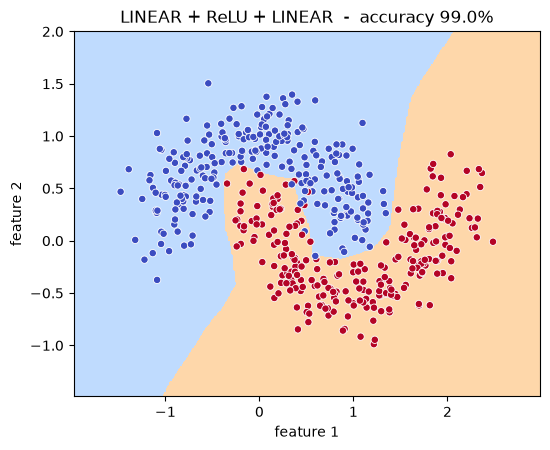

In [126]:
# ===== 1.3 เพิ่ม activation  =====
class MoonNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 32)   # 3 hidden layer H1:16, H2 32, H3 16 Activation ReLu
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))      # <<< บรรทัดเดียวที่ต่างจากอันบน
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))  
        x = self.fc4(x)      
        return x


torch.manual_seed(SEED)
model_mlp = MoonNet().to(DEVICE)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=0.1)
losses_mlp = []

for epoch in range(500):
    optimizer.zero_grad()
    pred = model_mlp(X)
    loss = loss_fn(pred, y)
    loss.backward()
    optimizer.step()
    losses_mlp.append(loss.item())

with torch.no_grad():
    acc_mlp = ((model_mlp(X) > 0).float() == y).float().mean().item()
print(f'accuracy = {acc_mlp:.1%}   (เส้นตรงได้ {acc_linear:.1%}, ถ้าไม่มี Activation ได้ {acc_stacked:.1%})')
plot_boundary(model_mlp, f'LINEAR + ReLU + LINEAR  -  accuracy {acc_mlp:.1%}',
              save_as='out_1_3_mlp_boundary.png')

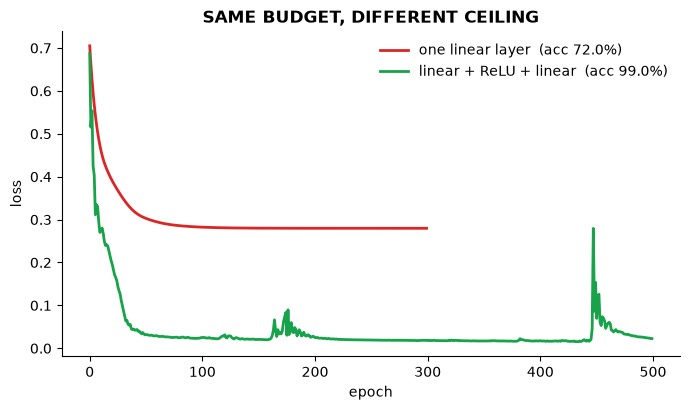

In [127]:
# เทียบ loss curve ของสองโมเดล 
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(losses_linear, label=f'one linear layer  (acc {acc_linear:.1%})', color='#dc2626', lw=2)
ax.plot(losses_mlp, label=f'linear + ReLU + linear  (acc {acc_mlp:.1%})', color='#16a34a', lw=2)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_title('SAME BUDGET, DIFFERENT CEILING', fontsize=12, weight='bold')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(IMG / 'out_1_3_loss_compare.png', dpi=150)
plt.show()

**รูปที่ 7** เส้นแบ่งโค้งห่อพระจันทร์ได้แล้ว ความแม่นยำเพิ่มจาก 86 ไป 98.6 %

**รูปที่ 8** loss ของโมเดลเส้นตรงลงไปได้ระดับหนึ่งแล้วไม่ลดลงอีก
ส่วนโมเดลที่มี ReLU ลงต่อได้เรื่อยๆ ทั้งที่ใช้ epoch เท่ากัน lr เท่ากัน

<img src="https://raw.githubusercontent.com/vasuprint/AI-CE564/main/weeks/W05_neuralnetwork/images/NN_Binary_EX1.png" width="900">

<sub>ที่มาของรูป: Tautology</sub>

<img src="https://raw.githubusercontent.com/vasuprint/AI-CE564/main/weeks/W05_neuralnetwork/images/NN_Binary_EX2.png" width="900">

<sub>ที่มาของรูป: Tautology</sub>

> **ลองเล่นเอง** เว็บ [TensorFlow Playground](https://playground.tensorflow.org) ให้กดเพิ่มลดชั้น
> และสลับ activation แล้วดูเส้นแบ่งว่ามีการขยับแบบ real time ลองเลือกข้อมูลรูปวงกลมหรือเกลียว
> แล้วปิด activation ดูว่าเทรนยังไงก็ไม่ผ่าน

---


## 1.4 การอ่านสถาปัตยกรรมและการออกแบบ Model

<img src="https://raw.githubusercontent.com/vasuprint/AI-CE564/main/weeks/W05_neuralnetwork/img_jupyter/fig05_architecture.png" width="760">

**รูปที่ 11** ข้อควรระวัง ตัวเลขตัวหลังของชั้นก่อน ต้องเท่ากับตัวเลขตัวหน้าของชั้นถัดไป

**แบบฝึกที่ 1 ให้ไดอะแกรม แล้วเขียนโค้ด** โครงสร้าง 2-16-8-1 แปลว่า input 2 ตัว
Hidden layer 16 หน่วย Hiddent layer 2 มี 8 หน่วย output 1 ตัว


In [128]:
# ===== 1.4 เขียนตามไดอะแกรม 2-16-8-1 =====
class DrillNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 16)      # 2 เข้า  16 ออก
        self.fc2 = nn.Linear(16, 8)      # 16 เข้า (ต้องตรงกับ 16 ข้างบน)  8 ออก
        self.fc3 = nn.Linear(8, 1)       # 8 เข้า (ต้องตรงกับ 8 ข้างบน)   1 ออก

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)                  # ชั้นสุดท้ายไม่ใส่ activation เพราะแยกของ 2 ชนิดใช้ BCE
        return x


drill = DrillNet().to(DEVICE)

# **แบบฝึกที่ 2 ให้โค้ด แล้วบอก shape** ไล่ดูทีละชั้นว่าข้อมูลเปลี่ยนรูปร่างยังไง
sample = torch.randn(4, 2, device=DEVICE)      # ข้อมูลปลอม 4 แถว 2 feature
print('input           ', tuple(sample.shape))
h1 = torch.relu(drill.fc1(sample))
print('หลัง fc1 + ReLU ', tuple(h1.shape))
h2 = torch.relu(drill.fc2(h1))
print('หลัง fc2 + ReLU ', tuple(h2.shape))
out = drill.fc3(h2)
print('หลัง fc3        ', tuple(out.shape))

print('\nน้ำหนักแต่ละชั้น')
for name, param in drill.named_parameters():
    print(f'  {name:12s} {tuple(param.shape)}')

input            (4, 2)
หลัง fc1 + ReLU  (4, 16)
หลัง fc2 + ReLU  (4, 8)
หลัง fc3         (4, 1)

น้ำหนักแต่ละชั้น
  fc1.weight   (16, 2)
  fc1.bias     (16,)
  fc2.weight   (8, 16)
  fc2.bias     (8,)
  fc3.weight   (1, 8)
  fc3.bias     (1,)


สังเกตว่าจำนวน shape[0] (row) (4) ไม่เปลี่ยนเลย เปลี่ยนแค่จำนวน shape [1] (columns)
เพราะแต่ละชั้นทำงานกับทุก row พร้อมกัน

ข้อควรระวังที่ทำให้สับสน: เราประกาศ nn.Linear(2, 16) = (in=2, out=16) แต่ PyTorch เก็บ weight เป็น (16, 2) = (out, in) กลับกัน! เพราะตอน forward มันคำนวณ $x W^T + b$:
$$\underbrace{(4, 2)}_{\text{ข้อมูล}} \times \underbrace{(2, 16)}_{W^T} = \underbrace{(4, 16)}_{\text{ผล}}$$

**ข้อสรุป** Hidden ไม่จำเป็นต้องเท่ากันทุกชั้น จะเป็น 16-8-4 หรือ 32-32 ก็ได้
สถาปัตยกรรมเป็นสิ่งที่ **ออกแบบได้**
ยิ่งหน่วยเยอะและชั้นลึก โมเดลยิ่งยืดหยุ่น เรียกว่ามี **capacity** สูง
ซึ่งอาจจะไม่ดีก็ได้

ข้อควรระวัง **bottle neck** คือบีบ Feature ให้ ผ่าน node ที่จำนวนน้อยจึงเกิด bottle neck

บทเรียนคือ capacity ของทั้งโมเดลถูกจำกัดด้วย **ชั้นที่แคบที่สุด** ไม่ใช่ชั้นที่กว้างที่สุด
เวลาออกแบบจึงนิยมไล่จากกว้างไปแคบทีละขั้น เช่น 32-16-8 ไม่ใช่กระโดดลงไปเหลือ 1 แล้วขยายกลับ

---


## 1.5 Learning rate และ optimizer

การปรับ Hyperparameter

<img src="https://raw.githubusercontent.com/vasuprint/AI-CE564/main/weeks/W05_neuralnetwork/img_jupyter/fig09_knobs.png" width="720">

**รูปที่ 13** A เปลี่ยนว่าโมเดล **ทำอะไรได้** B เปลี่ยนว่ามัน **ค้นหาน้ำหนักยังไง**
ดังนั้นเราจะมา Focus B หลังจากที่ทำ A ไปแล้วใน 1.3 - 1.4

เริ่มจาก **learning rate** คือขนาดก้าวในขั้นที่ 5 ของ loop ก้าวเล็กไปก็ถึงเป้าหมายช้า
ก้าวใหญ่ไปก็กระโดดข้าม Global minimum (Local minimum)

<img src="https://raw.githubusercontent.com/vasuprint/AI-CE564/main/weeks/W05_neuralnetwork/img_jupyter/fig10_learning_rate.png" width="880">

**รูปที่ 14** ภาพในอุดมคติของ lr 3 แบบบน loss land space


In [129]:
# ===== ทดลอง learning rate ใช้ SGD  =====
lr_results = {}

for lr in [0.01, 5.0, 20.0]:
    torch.manual_seed(SEED)
    m = MoonNet().to(DEVICE)  # Model ที่ 1.3
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(m.parameters(), lr=lr)
    hist = []

    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        loss = loss_fn(m(X), y)
        loss.backward()
        optimizer.step()
        hist.append(loss.item())

    with torch.no_grad():
        acc = ((m(X) > 0).float() == y).float().mean().item()
    lr_results[lr] = (hist, acc)
    print(f'lr = {lr:<6} loss สุดท้าย = {hist[-1]:.3f}   accuracy = {acc:.1%}')

lr = 0.01   loss สุดท้าย = 0.568   accuracy = 77.4%
lr = 5.0    loss สุดท้าย = 0.693   accuracy = 50.0%
lr = 20.0   loss สุดท้าย = 2.471   accuracy = 50.0%


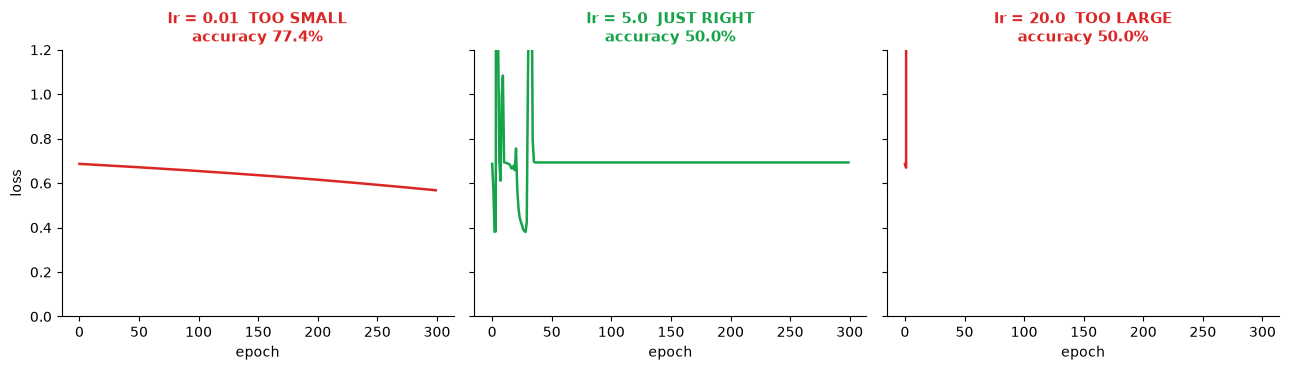

In [130]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
titles = ['lr = 0.01  TOO SMALL', 'lr = 5.0  JUST RIGHT', 'lr = 20.0  TOO LARGE']
colors = ['#dc2626', '#16a34a', '#dc2626']

for ax, (lr, (hist, acc)), title, color in zip(axes, lr_results.items(), titles, colors):
    ax.plot(hist, color=color, lw=1.8)
    ax.set_title(f'{title}\naccuracy {acc:.1%}', fontsize=11, weight='bold', color=color)
    ax.set_xlabel('epoch')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('loss')
axes[0].set_ylim(0, 1.2)
fig.tight_layout()
fig.savefig(IMG / 'out_1_5_lr.png', dpi=150)
plt.show()

**รูปที่ 15** ซ้ายคือ loss ค่อยๆ ลงแต่ยังไม่ถึงไหนตอนหมด epoch
ภาพที่ 2 คือ loss ค่อยๆลดลง ภาพขวาคือกระเด้งขึ้นลงไม่นิ่ง เพราะก้าวใหญ่เกินจนกระโดดข้ามจุดต่ำสุดไปมา

ข้อควรระวัง ค่า lr ที่ "พอดี" ไม่ใช่ตัวเลขที่สามารถใช้ได้กับทุก Model แต่ขึ้นกับ optimizer กับสเกลของข้อมูล
ตัวอย่างนี้ใช้ SGD เลยต้องใช้ lr ใหญ่ถึงจะขยับ ถ้าเป็น Adam ค่า 5.0 จะใหญ่เกินไปแล้ว

ต่อไปคือ **optimizer** ว่าจะนำ gradient ไปขยับน้ำหนัก (Weight) อย่างไร
`SGD` ขยับตรงตามความชันตรงๆ ส่วน `Adam` ปรับขนาดก้าวของน้ำหนักแต่ละตัวเองอัตโนมัติ


SGD   loss ที่ epoch 50 = 0.4664   loss สุดท้าย = 0.2606   accuracy = 86.4%
Adam  loss ที่ epoch 50 = 0.0314   loss สุดท้าย = 0.0181   accuracy = 98.8%


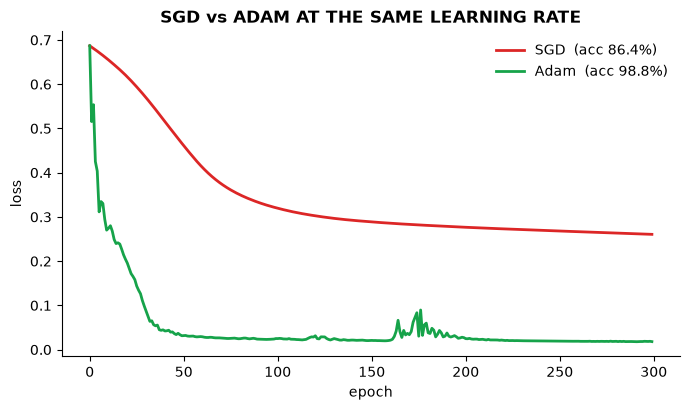

In [131]:
# ===== เทียบ SGD กับ Adam ที่ lr เท่ากัน =====
opt_results = {}

for name in ['SGD', 'Adam']:
    torch.manual_seed(SEED)
    m = MoonNet().to(DEVICE)
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = (torch.optim.SGD(m.parameters(), lr=0.1) if name == 'SGD'
                 else torch.optim.Adam(m.parameters(), lr=0.1))
    hist = []

    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        loss = loss_fn(m(X), y)
        loss.backward()
        optimizer.step()
        hist.append(loss.item())

    with torch.no_grad():
        acc = ((m(X) > 0).float() == y).float().mean().item()
    opt_results[name] = (hist, acc)
    print(f'{name:5s} loss ที่ epoch 50 = {hist[49]:.4f}   loss สุดท้าย = {hist[-1]:.4f}   accuracy = {acc:.1%}')

fig, ax = plt.subplots(figsize=(7, 4.2))
for name, color in [('SGD', '#dc2626'), ('Adam', '#16a34a')]:
    hist, acc = opt_results[name]
    ax.plot(hist, label=f'{name}  (acc {acc:.1%})', color=color, lw=2)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_title('SGD vs ADAM AT THE SAME LEARNING RATE', fontsize=12, weight='bold')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(IMG / 'out_1_5_optimizer.png', dpi=150)
plt.show()

**รูปที่ 16** ที่ lr เท่ากันและ epoch เท่ากัน Adam ลงเร็วกว่ามากและไปได้ลึกกว่า
ส่วน SGD ยังคลานอยู่ ทำให้ accuracy ต่างกันชัด

**สรุปว่าควรใช้อะไร** เริ่มที่ `Adam` กับ `lr=0.001` เสมอเป็นค่าตั้งต้นที่ปลอดภัย
แล้วค่อยปรับถ้าจำเป็น ส่วน SGD ยังใช้กันอยู่ในงานใหญ่ เพราะบางทีให้ผลสุดท้ายดีกว่าถ้า Tune ให้ดี

---


## Exercise 1

เขียนเองทั้งหมด ห้ามคัดลอกเซลล์ข้างบนมาแปะ ให้พิมพ์ใหม่เพื่อให้จำ loop ได้

0. ใช้ Data สังเคราะห์ จากขั้นตอนก่อนหน้า
1. เขียน `nn.Module` ที่มี Hidden layer 5 ชั้น ขนาด **8 หน่วย**
2. เลือก activation ReLU
3. เลือก loss ให้ตรงกับโจทย์ binary
4. เขียน training loop 5 ขั้นด้วยตัวเอง
5. ลองสลับ `SGD` กับ `Adam` แล้วพล็อต `plot_boundary` ดูว่าเส้นแบ่งต่างกันไหม

_คำใบ้_ output ของโจทย์ binary ที่ใช้คู่กับ `BCEWithLogitsLoss` ต้องมีกี่ node และใส่ activation หรือไม่


In [132]:
# ===== Exercise 1: เขียนตรงนี้ =====
class MyNet(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: ประกาศชั้นที่ต้องใช้
        pass

    def forward(self, x):
        # TODO: บอกว่าข้อมูลไหลยังไง
        pass


# TODO: สร้างโมเดล เลือก loss เลือก optimizer แล้วเขียน loop 5 ขั้น

---

## ตัวอย่าง Keras 


```python
import keras
from keras import layers

model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(2,)),
    layers.Dense(1, activation='sigmoid'),
])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.1),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X, y, epochs=300, verbose=0)
```

| | PyTorch | Keras |
|---|---|---|
| ประกาศโมเดล | `class` สืบทอด `nn.Module` | `keras.Sequential([...])` |
| ต่อชั้น | ระบุ in และ out เอง | ระบุแค่ out ตัว in คิดให้ |
| activation | เขียนใน `forward` | ใส่เป็น argument ของ layer |
| output binary | ไม่ใส่ activation ใช้ `BCEWithLogitsLoss` | ใส่ `sigmoid` ใช้ `binary_crossentropy` |
| การเทรน | เขียน loop 5 ขั้นเอง | `.fit()` |

> **จุดที่ต้องเข้าใจ** `.fit()` ของ Keras **ทำ 5 ขั้นตอนเดียวกัน**
> Keras เป็น wrap up ไว้ให้ไม่ต้องเขียน ข้อดีคือเขียนสั้น ข้อเสียคือตอนมีอะไรผิดปกติจะมองไม่เห็นว่า code ทำงานได้ถูกต้องไหม


---


In [133]:
# ===== ล้างค่า =====
del model, model_stacked, model_mlp, drill, optimizer, loss_fn
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('Finish')

Finish


<a id="sec2"></a>

# ช่วงที่ 2 การนำ Neural Network มาแก้ปัญหาจากโจทย์ 3 ประเภท

> **Code จากช่วงที่ 1 ใช้ได้กับทุกโจทย์ เปลี่ยนแค่ layer สุดท้ายกับ loss**

Model เลือก (Linear กับ ReLU สลับกันไป) กับ loop 5 ขั้น

<img src="https://raw.githubusercontent.com/vasuprint/AI-CE564/main/weeks/W05_neuralnetwork/img_jupyter/fig06_task_types.png" width="900">

**รูปที่ 17** โจทย์ 3 ประเภท ต่างกันแค่ Head กับ loss เท่านั้น


## 2.0 เตรียม Library


In [134]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
IMG = Path('images')
IMG.mkdir(exist_ok=True)
print('device =', DEVICE)

device = mps


---

## 2.1 โจทย์ Binary มะเร็งเต้านม (Binary เป็นหรือไม่เป็นมะเร็ง)

ชุดข้อมูล Breast Cancer Wisconsin ที่มากับ scikit-learn 569 แถว 30 feature
ตอบว่าก้อนเนื้อเป็นมะเร็งร้าย (malignant) หรือไม่ร้าย (benign)

**แบ่งข้อมูลสาม Data set**

- **train** ใช้เทรน โมเดลเห็น Dataset นี้ตลอด
- **validation** ใช้ตัดสินใจระหว่างทาง เช่นจะเลือก Model โครงสร้างไหน จะหยุดเทรนตอนไหน
- **test** แตะครั้งเดียวตอนจบ เพื่อรายงานผล


In [135]:
# ===== 2.1 โหลดและแบ่งข้อมูล =====
bc = load_breast_cancer()
X_all, y_all = bc.data, bc.target #ข้อมูลแบ่งมาให้่แล้วเป็น Train set  กับ Test set 

# แบ่งสามกอง 60 / 20 / 20
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)

X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=SEED, stratify=y_tmp) # ขั้นตอนการแบ่ง Validation จาก Train set 

print(f'train {X_train.shape}   val {X_val.shape}   test {X_test.shape}')
print(f'จำนวน feature = {X_all.shape[1]}')
print('\nสเกลของแต่ละ feature ต่างกันแค่ไหน (ดู 5 ตัวแรก)')
for i in range(5):
    print(f'  {bc.feature_names[i]:24s} ช่วง {X_train[:, i].min():8.3f} ถึง {X_train[:, i].max():8.3f}')

train (341, 30)   val (114, 30)   test (114, 30)
จำนวน feature = 30

สเกลของแต่ละ feature ต่างกันแค่ไหน (ดู 5 ตัวแรก)
  mean radius              ช่วง    6.981 ถึง   28.110
  mean texture             ช่วง    9.710 ถึง   39.280
  mean perimeter           ช่วง   43.790 ถึง  188.500
  mean area                ช่วง  143.500 ถึง 2499.000
  mean smoothness          ช่วง    0.063 ถึง    0.142


**สังเกตตรงนี้ให้ดี** feature บางตัวอยู่หลักพัน บางตัวอยู่หลักทศนิยม ต่างกันเป็นพันเท่า
นี่คือเหตุผลที่ต้องทำ `StandardScaler` ก่อนป้อนเข้า neural network

ทำไมมันสำคัญกับ NN เป็นพิเศษ เพราะ gradient ของน้ำหนักที่คูณกับ feature ตัวใหญ่
จะใหญ่ตามไปด้วยมาก พอใช้ learning rate ค่าเดียวกันทั้งโมเดล น้ำหนักบางตัวจะขยับมากเกินไป
ส่วนบางตัวแทบไม่ขยับเลย

**สำคัญมาก** `fit` scaler บน train เท่านั้น แล้ว `transform` ทั้งสาม dataset
ถ้า fit บนข้อมูลทั้งหมดคือ data leakage

ลองพิสูจน์ว่ามันต่างกันจริง เทรนสองรอบด้วย SGD ต่างกันแค่สเกลข้อมูล


In [136]:
# ===== พิสูจน์ว่าไม่ทำ scaling แล้วพังจริง =====
scaler = StandardScaler().fit(X_train)     # fit บน train เท่านั้น

class BinaryNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.fc1 = nn.Linear(n_features, 16) # เขียนเพื่อรองรับ Feature ของ Data เลย
        self.fc2 = nn.Linear(16, 1)        # binary: 1 node ไม่ใส่ activation

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)


for use_scaler in [False, True]:
    tr = scaler.transform(X_train) if use_scaler else X_train
    te = scaler.transform(X_test) if use_scaler else X_test
    Xtr = torch.tensor(tr, dtype=torch.float32, device=DEVICE)
    Xte = torch.tensor(te, dtype=torch.float32, device=DEVICE)
    ytr = torch.tensor(y_train, dtype=torch.float32, device=DEVICE).unsqueeze(1)
    yte = torch.tensor(y_test, dtype=torch.float32, device=DEVICE).unsqueeze(1)

    torch.manual_seed(SEED)
    m = BinaryNet(X_train.shape[1]).to(DEVICE)
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(m.parameters(), lr=0.01)

    first = None
    for epoch in range(200):
        optimizer.zero_grad()
        loss = loss_fn(m(Xtr), ytr)
        loss.backward()
        optimizer.step()
        if first is None:
            first = loss.item()

    with torch.no_grad():
        acc = ((m(Xte) > 0).float() == yte).float().mean().item()
    label = 'ทำ scaling   ' if use_scaler else 'ไม่ทำ scaling'
    print(f'{label}  loss เริ่มต้น = {first:8.3f}   loss สุดท้าย = {loss.item():.4f}   accuracy = {acc:.1%}')

ไม่ทำ scaling  loss เริ่มต้น =   30.549   loss สุดท้าย = 0.6692   accuracy = 63.2%
ทำ scaling     loss เริ่มต้น =    0.730   loss สุดท้าย = 0.3446   accuracy = 94.7%


ต่างกันมาก ตัวที่ไม่ได้ scale เริ่มด้วย loss สูงแล้วลงไม่ค่อยไหว
ส่วนตัวที่ scale แล้วเทรนได้ปกติ การทำ Scale สำหรับ Neural Network จึงจำเป็นต้องทำเสมอ แต่เป็นขั้นที่ข้ามไม่ได้

ทีนี้เทรน Model ด้วย Adam


In [137]:
# ===== 2.1 โมเดล binary  =====
Xtr = torch.tensor(scaler.transform(X_train), dtype=torch.float32, device=DEVICE)
Xva = torch.tensor(scaler.transform(X_val), dtype=torch.float32, device=DEVICE)
Xte = torch.tensor(scaler.transform(X_test), dtype=torch.float32, device=DEVICE)
ytr = torch.tensor(y_train, dtype=torch.float32, device=DEVICE).unsqueeze(1)
yva = torch.tensor(y_val, dtype=torch.float32, device=DEVICE).unsqueeze(1)
yte = torch.tensor(y_test, dtype=torch.float32, device=DEVICE).unsqueeze(1)

torch.manual_seed(SEED)
model_bin = BinaryNet(X_train.shape[1]).to(DEVICE)
loss_fn = nn.BCEWithLogitsLoss()                  # <<< loss ของโจทย์ binary
optimizer = torch.optim.Adam(model_bin.parameters(), lr=0.01)

for epoch in range(200):
    optimizer.zero_grad()
    pred = model_bin(Xtr)
    loss = loss_fn(pred, ytr)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 50 == 0:
        with torch.no_grad():
            va = ((model_bin(Xva) > 0).float() == yva).float().mean().item()
        print(f'epoch {epoch + 1:3d}  train loss = {loss.item():.4f}   val accuracy = {va:.1%}')

with torch.no_grad():
    acc_bin = ((model_bin(Xte) > 0).float() == yte).float().mean().item()
print(f'\naccuracy บน test set = {acc_bin:.1%}')

epoch  50  train loss = 0.0469   val accuracy = 97.4%
epoch 100  train loss = 0.0242   val accuracy = 99.1%
epoch 150  train loss = 0.0127   val accuracy = 99.1%
epoch 200  train loss = 0.0079   val accuracy = 98.2%

accuracy บน test set = 96.5%


บางครั้ง Optimizer ก็มีผลทำให้ Accuracy สามารถเพิ่มขึ้นได้


---

## 2.2 โจทย์ Multiclass — ตัวเลข MNIST

MNIST คือภาพตัวเลข 0 ถึง 9 ขนาด 28 คูณ 28 พิกเซล ต่างจากสองโจทย์ก่อนหน้าตรงที่

**คำตอบมี 10 คลาส ไม่ใช่ 2**

สิ่งที่ต้องเปลี่ยนจากโจทย์ binary

1. layer สุดท้ายมี **10 node** ไม่ใช่ 1 (หนึ่ง node ต่อหนึ่งคลาส)
2. loss เปลี่ยนเป็น `CrossEntropyLoss` ซึ่งมี softmax อยู่ข้างในแล้ว

<img src="https://raw.githubusercontent.com/vasuprint/AI-CE564/main/weeks/W05_neuralnetwork/images/NN_Multi-Class_EX1.png" width="900">

<sub>ที่มาของรูป: Tautology</sub>

**รูปที่ 18** ทำไมต้องมี node เท่าจำนวนคลาส ดูคอลัมน์ขวาสุดจะเห็น **สามเส้นแยกกัน**
ทุก node ใช้โครงสร้าง model (bottom) ร่วมกัน แต่ แต่แต่ละ node เรียนที่จะ แยก Class ออกจากช่วงของ input แตกต่างกันตามระนาบของ Prediction plane
พอผ่าน softmax แล้วทั้งสามค่า (แสดงในกรณีที่ มี target ทั้งหมด 3 class) จะถูกบีบให้รวมกันได้ 1 พอดี จึงอ่านเป็นความน่าจะเป็นของแต่ละคลาสได้

<img src="https://raw.githubusercontent.com/vasuprint/AI-CE564/main/weeks/W05_neuralnetwork/images/NN_Multi-Class_EX2.png" width="900">

<sub>ที่มาของรูป: Tautology</sub>

**รูปที่ 19** แสดงภาพแบบ 3 มิติ ในการแสดง **พื้นที่ตัดสินใจ (Prediction plane)** สามสีนั่นเอง ซึ่งเป็นเรื่องเดียวกับ decision boundary

**DataLoader**

เหตุผลที่ต้องใช้คือข้อมูลชุดนี้ใหญ่ ถ้ายัดทั้งก้อนเข้า GPU ทีเดียวแบบที่ทำมาตลอด (full-batch)
หน่วยความจำจะไม่พอ DataLoader จะหั่นข้อมูลเป็นก้อนย่อยเรียกว่า **batch** แล้วป้อนทีละก้อน จนครบ เมื่อครบจะเรียกว่า epoch
โดย loop จะ Train ชั้นนอก วนจนครบ epoch ที่กำหนด ส่วน ชั้นในวน batch นอกจากนั้น Data loader ยังแปลงภาพให้เป็น Tensor เพื่อนำมาฝึกสอน ให้กับ Model ได้

> ในคาบนี้เราสุ่มมาใช้ 10,000 ภาพจาก 60,000 ภาพ เพื่อให้รันจบไว
> ถ้ามี GPU และเวลาพอ เปลี่ยน `N_SUBSET` เป็น `None` เพื่อใช้ทั้งหมดได้


In [138]:
# ===== 2.2 โหลด MNIST ผ่าน DataLoader =====
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

N_SUBSET = 10_000          # ตั้งเป็น None ถ้าอยากใช้ทั้ง 60,000 ภาพ
BATCH_SIZE = 64     # ลองปรับเปลี่ยน batch ว่ามีผลอย่างไร 

tf = transforms.Compose([
    transforms.ToTensor(),                         # ภาพเป็น tensor ค่า 0 ถึง 1
    transforms.Normalize((0.1307,), (0.3081,)),    # scaling  ตามค่า ของสี 
])

train_full = datasets.MNIST(root='data', train=True, download=True, transform=tf)
test_set = datasets.MNIST(root='data', train=False, download=True, transform=tf)

if N_SUBSET is not None:
    g = torch.Generator().manual_seed(SEED)
    keep = torch.randperm(len(train_full), generator=g)[:N_SUBSET].tolist()
    train_set = Subset(train_full, keep)
else:
    train_set = train_full

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1000)

print(f'train {len(train_set)} ภาพ   test {len(test_set)} ภาพ   batch size {BATCH_SIZE}')
print(f'จำนวน batch ต่อ 1 epoch = {len(train_loader)}')

images, labels = next(iter(train_loader))
print(f'\nรูปร่างของ 1 batch: {tuple(images.shape)}  (batch, channel, สูง, กว้าง)')

train 10000 ภาพ   test 10000 ภาพ   batch size 64
จำนวน batch ต่อ 1 epoch = 157

รูปร่างของ 1 batch: (64, 1, 28, 28)  (batch, channel, สูง, กว้าง)


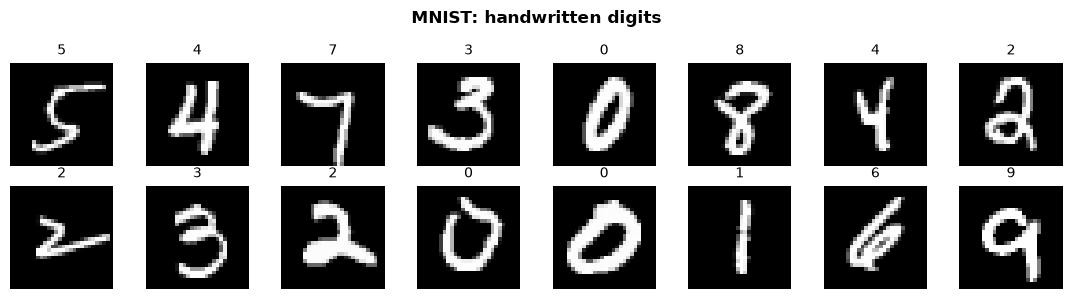

In [139]:
# ดูตัวอย่างของข้อมูล
fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for ax, img, lab in zip(axes.ravel(), images, labels):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(int(lab), fontsize=10)
    ax.axis('off')
fig.suptitle('MNIST: handwritten digits', fontsize=12, weight='bold')
fig.tight_layout()
fig.savefig(IMG / 'out_2_2_mnist_samples.png', dpi=150)
plt.show()

In [140]:
# ===== 2.2 โมเดล multiclass =====
class DigitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()          # 28x28 แผ่ออกเป็นเวกเตอร์ยาว 784 (784,1)
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 10)        # multiclass: 10 node ไม่ใส่ activation

    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x)) # ใส่ Activation Function
        return self.fc2(x)


torch.manual_seed(SEED)
model_mc = DigitNet().to(DEVICE)
loss_fn = nn.CrossEntropyLoss()                    # <<< loss ของโจทย์ multiclass
optimizer = torch.optim.Adam(model_mc.parameters(), lr=0.001)

EPOCHS = 5
for epoch in range(EPOCHS):
    running = 0.0
    for images, labels in train_loader:            # <<< loop ชั้นในที่เพิ่มมา
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()                      # 1
        pred = model_mc(images)                    # 2
        loss = loss_fn(pred, labels)               # 3
        loss.backward()                            # 4
        optimizer.step()                           # 5

        running += loss.item() * labels.size(0)
    print(f'epoch {epoch + 1}/{EPOCHS}  train loss เฉลี่ย = {running / len(train_set):.4f}')

correct = total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        correct += (model_mc(images).argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
acc_mc = correct / total
print(f'\naccuracy บน test set = {acc_mc:.1%}')

epoch 1/5  train loss เฉลี่ย = 0.5253
epoch 2/5  train loss เฉลี่ย = 0.2580
epoch 3/5  train loss เฉลี่ย = 0.1853
epoch 4/5  train loss เฉลี่ย = 0.1369
epoch 5/5  train loss เฉลี่ย = 0.1090

accuracy บน test set = 95.2%


In [141]:
print(labels, '\n')
print('Labels shape:',labels.shape)

tensor([7, 6, 1, 1, 0, 1, 2, 3, 4, 7, 2, 3, 4, 5, 6, 7, 0, 1, 2, 7, 8, 6, 3, 9,
        7, 1, 9, 3, 9, 6, 1, 7, 2, 4, 4, 5, 7, 0, 0, 1, 6, 6, 8, 2, 7, 7, 2, 4,
        2, 1, 6, 1, 0, 6, 9, 8, 3, 9, 6, 3, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1,
        2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 1, 6, 8, 9, 9, 0,
        1, 2, 4, 4, 3, 7, 4, 4, 4, 0, 3, 8, 7, 5, 8, 2, 1, 7, 5, 3, 8, 5, 2, 5,
        1, 1, 6, 2, 1, 3, 8, 6, 4, 2, 6, 2, 5, 5, 0, 2, 8, 0, 6, 8, 1, 7, 9, 1,
        9, 2, 6, 7, 6, 6, 8, 7, 4, 9, 2, 1, 3, 3, 0, 5, 5, 8, 0, 3, 7, 9, 7, 0,
        2, 7, 9, 1, 7, 8, 0, 3, 5, 3, 6, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2,
        3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 7, 8, 9, 6, 4, 2, 6, 4, 7, 8, 9, 2,
        9, 3, 9, 3, 0, 0, 1, 0, 4, 2, 6, 3, 5, 3, 0, 3, 4, 1, 5, 3, 0, 8, 3, 0,
        6, 1, 7, 8, 0, 9, 2, 6, 7, 1, 9, 6, 9, 4, 9, 9, 6, 7, 1, 2, 5, 3, 7, 8,
        0, 1, 2, 4, 5, 6, 7, 8, 9, 0, 1, 3, 4, 5, 6, 7, 8, 0, 1, 3, 4, 7, 8, 9,
        7, 5, 5, 1, 9, 9, 7, 1, 0, 0, 5,

**สังเกตความต่างของ target** โจทย์ binary ส่ง `y` เป็นทศนิยม shape `(N, 1)`
แต่ multiclass ส่ง `labels` เป็นจำนวนเต็ม shape `(N,)` ที่เก็บเลขคลาสตรงๆ คือ 0 ถึง 9
`CrossEntropyLoss` ต้องการแบบนี้ ([1000]) เป็น Matrix 1 d ไปเลย

Model ทำความแม่นยำได้ราว 95 เปอร์เซ็นต์จากโมเดลที่มีชั้นซ่อนชั้นเดียว โดยที่ยังไม่ได้ใช้ CNN เลย
เรื่อง CNN จะเรียนกันสัปดาห์ที่ 7

---

## 2.3 โจทย์ Regression ทำนายราคาบ้านในแคลิฟอร์เนีย

โจทย์สุดท้ายต่างจากสองอันแรกตรงที่ **คำตอบเป็นตัวเลขต่อเนื่อง ไม่ใช่คลาส**
เราทำนายราคาบ้านของแต่ละเขต หน่วยเป็นแสนดอลลาร์

> ใช้ California Housing แทน Boston Housing ที่เคยเป็นชุดมาตรฐาน
> เพราะ Boston ถูกถอดออกจาก scikit-learn แล้ว เนื่องจากมีตัวแปรที่สะท้อนอคติทางเชื้อชาติ

สิ่งที่เปลี่ยน layer สุดท้ายเหลือ 1 node ไม่ใส่ activation (ปล่อยให้ออกค่าอะไรก็ได้)
และ loss เปลี่ยนเป็น `MSELoss` ซึ่งวัดผลต่างยกกำลังสอง


In [142]:
# ===== 2.3 โจทย์ regression =====
ch = fetch_california_housing()
Xc_tmp, Xc_test, yc_tmp, yc_test = train_test_split(
    ch.data, ch.target, test_size=0.2, random_state=SEED)
Xc_train, Xc_val, yc_train, yc_val = train_test_split(
    Xc_tmp, yc_tmp, test_size=0.25, random_state=SEED)

sc = StandardScaler().fit(Xc_train)
Xtr_c = torch.tensor(sc.transform(Xc_train), dtype=torch.float32, device=DEVICE)
Xte_c = torch.tensor(sc.transform(Xc_test), dtype=torch.float32, device=DEVICE)
ytr_c = torch.tensor(yc_train, dtype=torch.float32, device=DEVICE).unsqueeze(1)
yte_c = torch.tensor(yc_test, dtype=torch.float32, device=DEVICE).unsqueeze(1)
print(f'train {Xc_train.shape}   test {Xc_test.shape}   feature = {ch.data.shape[1]}')


class HouseNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.fc1 = nn.Linear(n_features, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)        # regression: 1 node ไม่ใส่ activation

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # มาใส่ตรงนี้ Activation
        x = torch.relu(self.fc2(x))  # มาใส่ตรงนี้ Activation
        return self.fc3(x)          # ไม่ต้องใส่ Activation


torch.manual_seed(SEED)
model_reg = HouseNet(ch.data.shape[1]).to(DEVICE)
loss_fn = nn.MSELoss()                             # <<< loss ของโจทย์ regression
optimizer = torch.optim.Adam(model_reg.parameters(), lr=0.01)

for epoch in range(400):
    optimizer.zero_grad()
    loss = loss_fn(model_reg(Xtr_c), ytr_c)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 100 == 0:
        print(f'epoch {epoch + 1:3d}  train MSE = {loss.item():.4f}')

with torch.no_grad():
    pred_c = model_reg(Xte_c)
    mae = (pred_c - yte_c).abs().mean().item()
    rmse = ((pred_c - yte_c) ** 2).mean().sqrt().item()
print(f'\nMAE  = {mae:.3f} แสนดอลลาร์  (ทายพลาดเฉลี่ยประมาณ {mae * 100:.0f},000 ดอลลาร์)')
print(f'RMSE = {rmse:.3f}')

train (12384, 8)   test (4128, 8)   feature = 8
epoch 100  train MSE = 0.3991
epoch 200  train MSE = 0.3348
epoch 300  train MSE = 0.3114
epoch 400  train MSE = 0.3013

MAE  = 0.389 แสนดอลลาร์  (ทายพลาดเฉลี่ยประมาณ 39,000 ดอลลาร์)
RMSE = 0.567


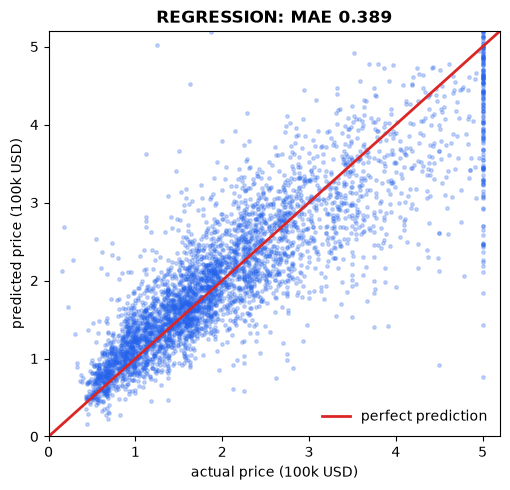

In [143]:
# พล็อตค่าจริงเทียบค่าทาย ถ้าโมเดลสมบูรณ์แบบจุดจะเรียงบนเส้นทแยง (prediction line)
fig, ax = plt.subplots(figsize=(5.2, 5))
p = pred_c.cpu().numpy().ravel()
t = yte_c.cpu().numpy().ravel()
ax.scatter(t, p, s=6, alpha=0.25, color='#2563eb')
lims = [0, 5.2]
ax.plot(lims, lims, color='#dc2626', lw=2, label='perfect prediction')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('actual price (100k USD)')
ax.set_ylabel('predicted price (100k USD)')
ax.set_title(f'REGRESSION: MAE {mae:.3f}', fontsize=12, weight='bold')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(IMG / 'out_2_3_regression.png', dpi=150)
plt.show()

**รูปที่ 20** จุดเกาะรอบเส้นแดงพอสมควร แปลว่าโมเดลใช้ได้ระดับหนึ่ง
สังเกตแถวบนขวาที่จุดเรียงเป็นแนวนอนตรงค่า 5 พอดี เพราะชุดข้อมูลนี้ตัดเพดานราคาไว้ที่ 500,000 ดอลลาร์
ค่าที่แพงกว่านั้นถูกบันทึกเป็น 5 หมด โมเดลจึงทายเกินไม่ได้ นี่คือข้อจำกัดของข้อมูล ไม่ใช่ของโมเดล

---

## สรุปช่วงที่

| ประเภท     | layer สุดท้าย | activation ที่ output | loss                | metric     |
| ---------- | ------------- | --------------------- | ------------------- | ---------- |
| Binary     | 1 node        | ไม่มี (logits)        | `BCEWithLogitsLoss` | accuracy   |
| Multiclass | N node        | ไม่มี (logits)        | `CrossEntropyLoss`  | accuracy   |
| Regression | 1 node        | ไม่มี                 | `MSELoss`           | MAE / RMSE |

สังเกตว่าคอลัมน์ activation เป็นไม่ต้องใส่ ทั้งสามแบบฝึกหัดใน Layer สุดท้าย ซึ่งเป็นข้อควรระวัง

> ### ข้อควรระวังของ PyTorch
>
> `BCEWithLogitsLoss` มี **sigmoid** อยู่ข้างในแล้ว
> `CrossEntropyLoss` มี **softmax** อยู่ข้างในแล้ว
>
> ทั้งคู่รับ **raw logits** คือค่าจาก `nn.Linear` ตรงๆ
> ถ้าเผลอใส่ `sigmoid` หรือ `softmax` ที่ output เองด้วย จะกลายเป็นใส่ซ้ำสองรอบ
> ผลคือ gradient แบน (ไม่ปรับ) จนโมเดล **ไม่เทรนเลย** และที่จะไม่มี error แสดงให้เห็น
> มันจะเทรนไปเงียบๆ แล้วได้ผลแย่ ทำให้หาสาเหตุยากมาก
>
> ถ้าอยากได้ความน่าจะเป็นออกมาดู ค่อยใส่ `torch.sigmoid()` หรือ `torch.softmax()`
> **ตอนทำนายเท่านั้น** ไม่ใช่ตอนเทรน

---

## Exercise 2

เขียน `nn.Module` ให้ครบทั้ง 3 โจทย์ โดยเลือก output layer กับ loss ให้ถูกเอง

1. โจทย์ binary มี 20 feature ชั้นซ่อน 1 ชั้น 16 หน่วย
2. โจทย์ multiclass 5 คลาส มี 12 feature ชั้นซ่อน 2 ชั้น 32 และ 16 หน่วย
3. โจทย์ regression มี 8 feature ชั้นซ่อน 1 ชั้น 24 หน่วย

แต่ละข้อให้บอกด้วยว่าใช้ loss ตัวไหน และ output มีกี่ node ใส่ activation หรือไม่


In [144]:
# ===== Exercise 2: เขียนตรงนี้ =====
# TODO ข้อ 1: binary  20 feature, hidden 16
# TODO ข้อ 2: multiclass 5 คลาส  12 feature, hidden 32 และ 16
# TODO ข้อ 3: regression  8 feature, hidden 24

---

## ตัวอย่าง Keras 

```python
import keras
from keras import layers

# --- binary ---
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(30,)),
    layers.Dense(1, activation='sigmoid'),
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- multiclass ---
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax'),
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',   # label เป็นเลขคลาส ไม่ใช่ one-hot
              metrics=['accuracy'])

# --- regression ---
model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(8,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1),                                     # ไม่ใส่ activation
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
```

**จุดต่างที่ต้องระวังเวลาอ่านโค้ด Keras เทียบ PyTorch**

| | PyTorch | Keras |
|---|---|---|
| binary output | ไม่ใส่ activation + `BCEWithLogitsLoss` | ใส่ `sigmoid` + `binary_crossentropy` |
| multiclass output | ไม่ใส่ activation + `CrossEntropyLoss` | ใส่ `softmax` + `sparse_categorical_crossentropy` |
| batch | สร้าง `DataLoader` เอง | ใส่ `batch_size=` ใน `.fit()` |

สังเกตว่า **Keras ใส่ activation ที่ output แต่ PyTorch ไม่ใส่** 
เพราะ PyTorch เลือกรวมขั้นนั้นเข้าไปใน loss 

---


In [145]:
# === ล้าง GD =====
del model_bin, model_mc, model_reg, optimizer, loss_fn
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('Finish')

Finish


---

<a id="sec3"></a>

# ช่วงที่ 3 Overfitting และวิธี Generalize model (ป้องกันไม่ให้ Overfitting)

ในช่วงที่ 1 เราบอกว่ายิ่งหน่วยเยอะชั้นลึก โมเดลยิ่งยืดหยุ่น เรียกว่ามี **capacity** สูง
ซึ้งดูเหมือนจะเป็นเรื่องที่ดี

โมเดลที่ยืดหยุ่นเกินความจำเป็น จะไม่ได้เรียน **แบบแผน (Pattern)** ของข้อมูล
แต่ไป **จำหรือเรียนรู้ Noise** ข้อมูลของชุดฝึกทีละจุดรวมทั้ง noise ที่ติดมาด้วย
พอเจอข้อมูลใหม่ที่ไม่เคยเห็นก็ทายพลาด อาการนี้เรียกว่า **overfitting**

เราจะใช้โจทย์ 1 มิติคือ fit เส้น sine ที่มี noise เพราะเห็นภาพชัดที่สุด
ตาเรามองออกทันทีว่าเส้นไหนวิ่งไล่จุด noise และเส้นไหนจับ Pattern ได้จริง

## 3 เตรียม Library


device = mps


/var/folders/j8/b5w034xj3vd8qbv6vk46d43r0000gn/T/ipykernel_39367/3283436141.py:35: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax.plot(x_dense.cpu(), np.sin(x_dense.cpu()), color='#64748b', lw=2, ls='--', label='true pattern: sin(x)')


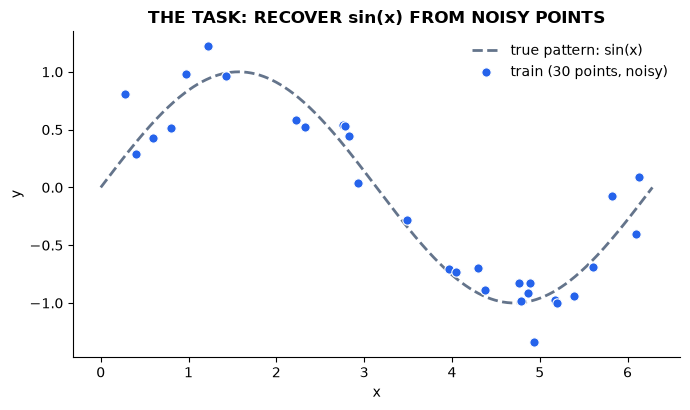

In [146]:
# ===== ช่วงที่ 3: import และข้อมูลของช่วงนี้เอง =====
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
IMG = Path('images')
IMG.mkdir(exist_ok=True)
print('device =', DEVICE)

# ข้อมูลน้อยและมี noise คือสูตรสำเร็จของ overfitting
N_TRAIN, N_VAL, NOISE = 30, 200, 0.25  # เพิ่ม Noise เข้าไป 
rng = np.random.default_rng(SEED)

x_train_np = np.sort(rng.uniform(0, 2 * np.pi, N_TRAIN))
y_train_np = np.sin(x_train_np) + rng.normal(0, NOISE, N_TRAIN)
x_val_np = np.sort(rng.uniform(0, 2 * np.pi, N_VAL))
y_val_np = np.sin(x_val_np) + rng.normal(0, NOISE, N_VAL)

x_train = torch.tensor(x_train_np, dtype=torch.float32, device=DEVICE).unsqueeze(1)
y_train = torch.tensor(y_train_np, dtype=torch.float32, device=DEVICE).unsqueeze(1)
x_val = torch.tensor(x_val_np, dtype=torch.float32, device=DEVICE).unsqueeze(1)
y_val = torch.tensor(y_val_np, dtype=torch.float32, device=DEVICE).unsqueeze(1)

x_dense = torch.linspace(0, 2 * np.pi, 400, device=DEVICE).unsqueeze(1)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(x_dense.cpu(), np.sin(x_dense.cpu()), color='#64748b', lw=2, ls='--', label='true pattern: sin(x)')
ax.scatter(x_train_np, y_train_np, color='#2563eb', s=45, zorder=3,
           edgecolor='white', linewidth=0.8, label=f'train ({N_TRAIN} points, noisy)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('THE TASK: RECOVER sin(x) FROM NOISY POINTS', fontsize=12, weight='bold')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(IMG / 'out_3_0_data.png', dpi=150)
plt.show()

**รูปที่ 21** เส้นประเทาคือpatternที่เราอยากให้โมเดลค้นพบ
จุดน้ำเงินคือข้อมูลที่โมเดลเห็นจริง ซึ่งเบี่ยงจากเส้นจริงเพราะมี noise

**สิ่งที่เราอยากได้** คือโมเดลวาดเส้นใกล้เส้นประ
**สิ่งที่จะเกิดขึ้นจริง** คือโมเดลใหญ่จะพยายามวิ่งผ่านจุดน้ำเงินให้ครบทุกจุด

<img src="https://raw.githubusercontent.com/vasuprint/AI-CE564/main/weeks/W05_neuralnetwork/images/NN_Regression_EX2.png" width="820">

<sub>ที่มาของรูป: Tautology</sub>

**รูปที่ 22** Hidden layerแค่ 4 หน่วยก็ประกอบเป็นคลื่น sine ได้
แต่ละหน่วยรับผิดชอบ "การหักมุม 1 ครั้ง" พอเอามาบวกกันจึงได้เส้นที่ขึ้นลงตามคลื่น

ตรงนี้คือจุดที่จำทำให้ overfitting ที่กำลังจะเจอ ถ้า 4 หน่วยพอดีกับ sine
แล้วเราให้ไป **128 หน่วย 2 Hidden layer** มันจะเอาหน่วยที่เหลือไปทำอะไร
คำตอบคือเอาไปหักมุมเพิ่มเพื่อวิ่งไล่จุด noise ทีละจุด ซึ่งคือสิ่งที่จะได้เห็นใน

---

## 3.1 การทำให้ Model Over-fitting

ใช้โมเดลใหญ่เกินตัวคือ 1-128-128-1 กับข้อมูลแค่ 30 จุด แล้วเทรน
วัด loss ทั้งฝั่ง train และ val ทุก epoch เพื่อดูว่ามันแยกจากกันตอนไหน


In [147]:
class CurveNet(nn.Module):
    def __init__(self, hidden=128, p_drop=0.0):
        super().__init__()
        self.fc1 = nn.Linear(1, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, 1)
        self.drop = nn.Dropout(p_drop)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.drop(x)
        x = torch.relu(self.fc2(x))
        x = self.drop(x)
        return self.fc3(x)


EPOCHS = 3000
torch.manual_seed(SEED)
model_over = CurveNet().to(DEVICE)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model_over.parameters(), lr=0.01)

hist_train, hist_val = [], []
for epoch in range(EPOCHS):
    model_over.train()
    optimizer.zero_grad()
    loss = loss_fn(model_over(x_train), y_train)
    loss.backward()
    optimizer.step()

    model_over.eval()
    with torch.no_grad():
        vl = loss_fn(model_over(x_val), y_val)
    hist_train.append(loss.item())
    hist_val.append(vl.item())

best_epoch = int(np.argmin(hist_val))
print(f'train loss สุดท้าย = {hist_train[-1]:.4f}')
print(f'val   loss สุดท้าย = {hist_val[-1]:.4f}')
print(f'val   loss ต่ำสุด  = {hist_val[best_epoch]:.4f} ที่ epoch {best_epoch + 1}')
print(f'\nช่องว่าง (gap)  = {hist_val[-1] - hist_train[-1]:.4f}')

train loss สุดท้าย = 0.0126
val   loss สุดท้าย = 0.1790
val   loss ต่ำสุด  = 0.1220 ที่ epoch 44

ช่องว่าง (gap)  = 0.1665


/var/folders/j8/b5w034xj3vd8qbv6vk46d43r0000gn/T/ipykernel_39367/1364712411.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax.plot(x_dense.cpu(), np.sin(x_dense.cpu()), color='#64748b', lw=2, ls='--', label='true sin(x)')


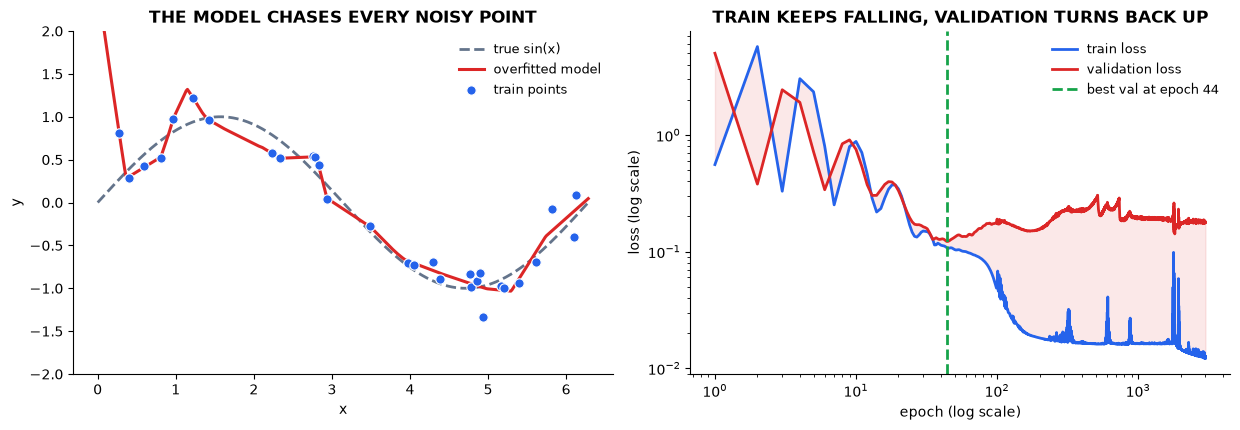

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

# ซ้าย: เส้นที่โมเดลวาด
ax = axes[0]
model_over.eval()
with torch.no_grad():
    y_pred = model_over(x_dense).cpu()
ax.plot(x_dense.cpu(), np.sin(x_dense.cpu()), color='#64748b', lw=2, ls='--', label='true sin(x)')
ax.plot(x_dense.cpu(), y_pred, color='#dc2626', lw=2.2, label='overfitted model')
ax.scatter(x_train_np, y_train_np, color='#2563eb', s=45, zorder=3,
           edgecolor='white', linewidth=0.8, label='train points')
ax.set_title('THE MODEL CHASES EVERY NOISY POINT', fontsize=12, weight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_ylim(-2.0, 2.0)
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ขวา: loss curve
ax = axes[1]
epochs_axis = np.arange(1, EPOCHS + 1)
ax.plot(epochs_axis, hist_train, color='#2563eb', lw=2, label='train loss')
ax.plot(epochs_axis, hist_val, color='#dc2626', lw=2, label='validation loss')
ax.axvline(best_epoch + 1, color='#16a34a', ls='--', lw=2, label=f'best val at epoch {best_epoch + 1}')
ax.fill_between(epochs_axis, hist_train, hist_val, color='#dc2626', alpha=0.10)
ax.set_xscale('log')          # แกน log ทำให้ช่วง epoch ต้นๆ ที่ val เด้งกลับขึ้น
ax.set_yscale('log')
ax.set_xlabel('epoch (log scale)')
ax.set_ylabel('loss (log scale)')
ax.set_title('TRAIN KEEPS FALLING, VALIDATION TURNS BACK UP', fontsize=12, weight='bold')
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
fig.savefig(IMG / 'out_3_1_overfit.png', dpi=150)
plt.show()

**รูปที่ 23** ซ้ายคือเส้นแดงที่บิดไปมาเพื่อวิ่งผ่านจุดน้ำเงินให้ครบ ซึ่งไม่ใช่รูปร่างของ sine
ขวาคือหลักฐานโดยแสดงในรูปแบบ log scale เพื่อให้เห็น train loss (น้ำเงิน) ลงเรื่อยๆ ไม่มีหยุด
แต่ val loss (แดง) ลงถึงจุดหนึ่งแล้ว **เด้งกลับขึ้น** พื้นที่ช่องว่างสีแดงคือช่องว่างที่ถ่างขึ้นเรื่อยๆ

แกนนอนของรูปขวาเป็น log เพราะจุดกลับตัวเกิดเร็วมากคือราว epoch ที่ 44
ถ้าใช้ scale ธรรมดาจะมองไม่ทันเพราะ Train ยาวถึง 3000 ช่วง โดยช่วงเลี้ยวจะถูกบีบจนมองไม่เห็น

ข้อควรระวังออกแบบหรือเลือกใช้ โมเดลใหญ่บนข้อมูลน้อยจะเริ่ม overfit **เร็วกว่าที่คิดมาก**

<img src="https://raw.githubusercontent.com/vasuprint/AI-CE564/main/weeks/W05_neuralnetwork/img_jupyter/fig07_overfit.png" width="620">

**รูปที่ 24** ภาพในอุดมคติของอาการเดียวกัน ซ้ายมือคือ underfit ยังเรียนไม่พอ
ขวามือคือ overfit เรียนเกินจนจำ noise จุดที่ดีที่สุดคือตรงที่ val loss ต่ำสุด

> **บทเรียนสำคัญ** train loss ที่ต่ำลงเรื่อยๆ **ไม่ได้แปลว่าโมเดลดีขึ้น**
> ต้องดู validation ควบคู่เสมอ ถ้าดูแต่ train จะคิดว่าเทรนยิ่งนานยิ่งดี

**ทำไมถึงเกิด** สองเหตุผลรวมกัน
หนึ่ง **capacity สูงเกินงาน Model มีความซับซ้อนหรือเก่งมากเกินไป** พารามิเตอร์หลักหมื่นตัวกับข้อมูล 30 จุด ทำให้ Model ไปเรียนรู้กับ Noise
การ **เทรนนานเกินไป** epoch ยิ่งเยอะ ยิ่งมีโอกาสที่ทำให้เกิดการเรียนรู้กับ noise มากขึ้น

---

## 3.2 สามวิธีคุม overfitting

<img src="https://raw.githubusercontent.com/vasuprint/AI-CE564/main/weeks/W05_neuralnetwork/img_jupyter/fig08_regularization.png" width="900">

**รูปที่ 25** การแก้ปัญหา Overfitting

1. **Dropout** สุ่มปิด node บางตัวทิ้งระหว่างเทรน โมเดลจึงพึ่ง node ใด node หนึ่งมากไม่ได้
   ต้องกระจายความรู้ให้ทั่ว ตอนทำนายจริงจะเปิดครบทุก node
2. **Weight decay** เพิ่มบทลงโทษ (การปรับ Gradient) ให้น้ำหนักที่ใหญ่ โมเดลจึงเลือก Prediction line (Space) ที่ซับซ้อนน้อยกว่า
   ใน PyTorch ใส่เป็น argument `weight_decay` ของ optimizer ได้เลย
3. **Early stopping** หยุดเทรนตรงที่ val loss ต่ำสุด แล้วเก็บ weight ตอนนั้นไว้

**เรื่อง `model.train()` กับ `model.eval()`** สองบรรทัดนี้จำเป็นเมื่อมี dropout
เพราะ dropout ต้องทำงานตอนเทรน แต่ต้องปิดตอนประเมินผล ถ้าลืมสลับ ผลที่วัดจะมั่วและไม่สามารถประเมินผลได้


In [149]:
# ===== 3.2 เทรนสี่แบบเทียบกัน =====
configs = [
    ('no control',    dict(p_drop=0.0, weight_decay=0.0),   '#dc2626'),
    ('dropout 0.2',   dict(p_drop=0.2, weight_decay=0.0),   '#ea580c'),
    ('weight decay',  dict(p_drop=0.0, weight_decay=1e-2),  '#2563eb'),
    ('both',          dict(p_drop=0.2, weight_decay=1e-2),  '#16a34a'),
]
results = {}

for name, cfg, color in configs:
    torch.manual_seed(SEED)
    m = CurveNet(p_drop=cfg['p_drop']).to(DEVICE)
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(m.parameters(), lr=0.01, weight_decay=cfg['weight_decay'])

    tr_hist, va_hist = [], []
    best_val, best_state, best_ep = float('inf'), None, 0

    for epoch in range(EPOCHS):
        m.train()
        optimizer.zero_grad()
        loss = loss_fn(m(x_train), y_train)
        loss.backward()
        optimizer.step()

        m.eval()
        with torch.no_grad():
            vl = loss_fn(m(x_val), y_val).item()
        tr_hist.append(loss.item())
        va_hist.append(vl)

        if vl < best_val:                                    # early stopping: จำสถานะที่ดีที่สุดไว้
            best_val, best_ep = vl, epoch
            best_state = {k: v.clone() for k, v in m.state_dict().items()}

    results[name] = dict(model=m, tr=tr_hist, va=va_hist, color=color,
                         best_val=best_val, best_ep=best_ep, best_state=best_state)
    gap = va_hist[-1] - tr_hist[-1]
    print(f'{name:14s} train {tr_hist[-1]:.4f}   val {va_hist[-1]:.4f}   '
          f'gap {gap:.4f}   val ดีสุด {best_val:.4f} (epoch {best_ep + 1})')

no control     train 0.0126   val 0.1790   gap 0.1665   val ดีสุด 0.1220 (epoch 44)
dropout 0.2    train 0.0345   val 0.1570   gap 0.1225   val ดีสุด 0.1048 (epoch 508)
weight decay   train 0.0378   val 0.0747   gap 0.0370   val ดีสุด 0.0730 (epoch 2456)
both           train 0.0797   val 0.0908   gap 0.0111   val ดีสุด 0.0863 (epoch 2810)


/var/folders/j8/b5w034xj3vd8qbv6vk46d43r0000gn/T/ipykernel_39367/3623537891.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax.plot(x_dense.cpu(), np.sin(x_dense.cpu()), color='#64748b', lw=2.5, ls='--', label='true sin(x)')


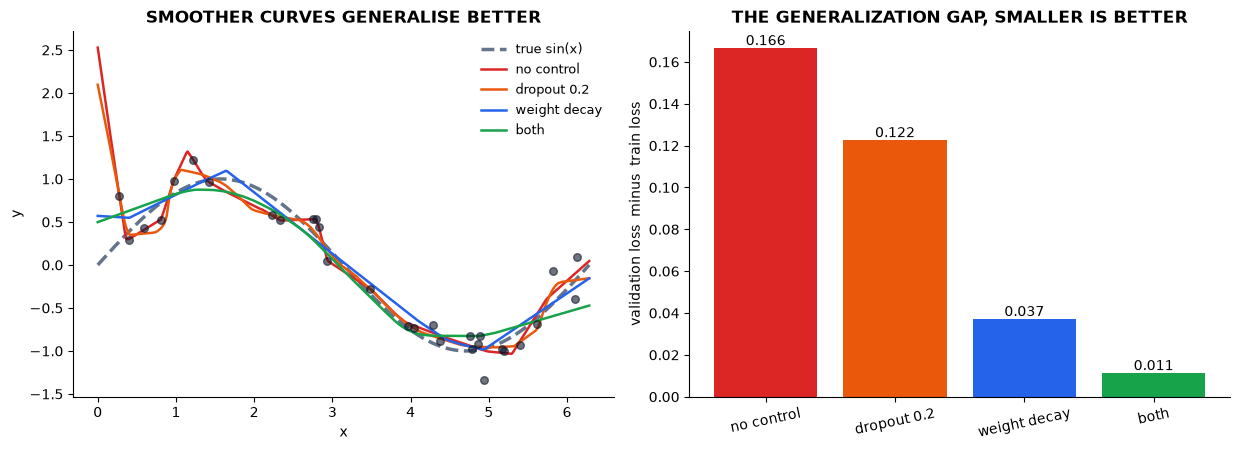

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

# ซ้าย: เส้นที่วาดได้ของแต่ละแบบ
ax = axes[0]
ax.plot(x_dense.cpu(), np.sin(x_dense.cpu()), color='#64748b', lw=2.5, ls='--', label='true sin(x)')
for name, r in results.items():
    r['model'].eval()
    with torch.no_grad():
        ax.plot(x_dense.cpu(), r['model'](x_dense).cpu(), color=r['color'], lw=1.8, label=name)
ax.scatter(x_train_np, y_train_np, color='#0f172a', s=30, zorder=3, alpha=0.6)
ax.set_title('SMOOTHER CURVES GENERALISE BETTER', fontsize=12, weight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ขวา: gap ของแต่ละแบบ
ax = axes[1]
names = list(results)
gaps = [results[n]['va'][-1] - results[n]['tr'][-1] for n in names]
bars = ax.bar(names, gaps, color=[results[n]['color'] for n in names])
for b, g in zip(bars, gaps):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f'{g:.3f}',
            ha='center', va='bottom', fontsize=10)
ax.set_ylabel('validation loss  minus  train loss')
ax.set_title('THE GENERALIZATION GAP, SMALLER IS BETTER', fontsize=12, weight='bold')
ax.tick_params(axis='x', rotation=12)
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
fig.savefig(IMG / 'out_3_2_regularization.png', dpi=150)
plt.show()

**รูปที่ 26** ซ้ายคือเส้นแดง (ไม่คุมอะไร) ที่ยังบิดไปมา เทียบกับเส้นอื่นที่เรียบกว่าและใกล้เส้นประมากกว่า
ขวาคือช่องว่างระหว่าง val กับ train ยิ่งเตี้ยยิ่งดี

---

## 3.3 Early stopping

สองวิธีแรกเปลี่ยนตัวโมเดล แต่ early stopping ไม่ยุ่งกับโมเดลเลย
มันแค่ **เลือกช่วงเวลาที่ต้องหยุด Train** คือเก็บน้ำหนักตอนที่ val loss ต่ำสุดไว้ แล้วหยุด Train
ในโค้ดข้างบนเราเก็บ `best_state` ไว้แล้ว ทีนี้เอามาใช้จริง


เทรนจนครบ 3000 epoch      val loss = 0.1790
หยุดที่ epoch 44             val loss = 0.1220

ดีขึ้น 31.8% โดยไม่ต้องแก้โมเดลเลยสักบรรทัด


/var/folders/j8/b5w034xj3vd8qbv6vk46d43r0000gn/T/ipykernel_39367/2240232277.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax.plot(x_dense.cpu(), np.sin(x_dense.cpu()), color='#64748b', lw=2.5, ls='--', label='true sin(x)')


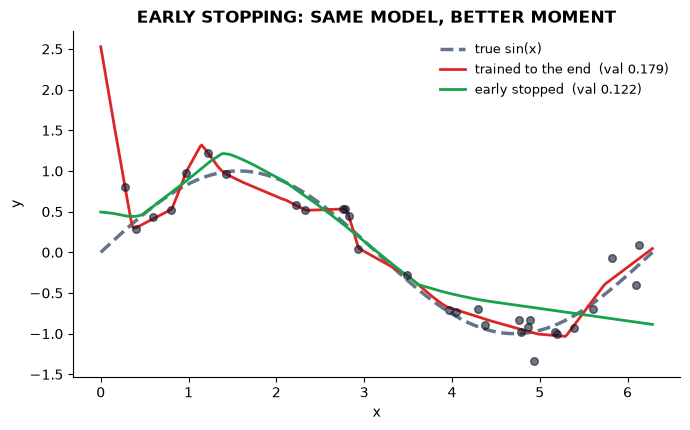

In [151]:
# ===== 3.3 โหลดน้ำหนักที่ดีที่สุดกลับมา แล้วเทียบกับตอนเทรนจนจบ =====
r = results['no control']
m_final = CurveNet().to(DEVICE)
m_final.load_state_dict(r['model'].state_dict())      # น้ำหนักตอน epoch สุดท้าย
m_best = CurveNet().to(DEVICE)
m_best.load_state_dict(r['best_state'])               # น้ำหนักตอน val ดีที่สุด

loss_fn = nn.MSELoss()
m_final.eval()
m_best.eval()
with torch.no_grad():
    vl_final = loss_fn(m_final(x_val), y_val).item()
    vl_best = loss_fn(m_best(x_val), y_val).item()

print(f'เทรนจนครบ {EPOCHS} epoch      val loss = {vl_final:.4f}')
print(f'หยุดที่ epoch {r["best_ep"] + 1:<14d} val loss = {vl_best:.4f}')
print(f'\nดีขึ้น {(vl_final - vl_best) / vl_final:.1%} โดยไม่ต้องแก้โมเดลเลยสักบรรทัด')

fig, ax = plt.subplots(figsize=(7, 4.4))
ax.plot(x_dense.cpu(), np.sin(x_dense.cpu()), color='#64748b', lw=2.5, ls='--', label='true sin(x)')
with torch.no_grad():
    ax.plot(x_dense.cpu(), m_final(x_dense).cpu(), color='#dc2626', lw=2,
            label=f'trained to the end  (val {vl_final:.3f})')
    ax.plot(x_dense.cpu(), m_best(x_dense).cpu(), color='#16a34a', lw=2,
            label=f'early stopped  (val {vl_best:.3f})')
ax.scatter(x_train_np, y_train_np, color='#0f172a', s=30, zorder=3, alpha=0.6)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('EARLY STOPPING: SAME MODEL, BETTER MOMENT', fontsize=12, weight='bold')
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(IMG / 'out_3_3_early_stopping.png', dpi=150)
plt.show()


**รูปที่ 27** โมเดลตัวเดียวกัน โครงสร้างเดียวกัน ต่างกันแค่หยุดเมื่อไร

**สรุปวิธีคุม overfitting**

| วิธี           | ทำอะไร                     | เหมาะสำหรับ           | ข้อควรระวัง                            |
| -------------- | -------------------------- | --------------------- | -------------------------------------- |
| Dropout        | สุ่มปิดหน่วยตอนเทรน        | โมเดลใหญ่ ชั้นเยอะ    | ต้องสลับ `train()` กับ `eval()` ให้ถูก |
| Weight decay   | ลงโทษน้ำหนักที่ใหญ่        | ใช้ได้เกือบทุกงาน     | ค่ามากไปทำให้ underfit                 |
| Early stopping | หยุดตรงจุดที่ val ดีที่สุด | ถูกและได้ผลเสมอ       | ต้องมี validation set จริง             |
| ลด capacity    | ใช้ชั้นน้อยลงหน่วยน้อยลง   | ข้อมูลน้อย            | เล็กไปก็ underfit                      |
| เพิ่มข้อมูล    | หาข้อมูลมาเพิ่ม            | ได้ผลดีที่สุดถ้าทำได้ | มักมี cost เพิ่มหรือทำไม่ได้           |

ในทางปฏิบัติมักใช้หลายวิธีพร้อมกัน และเกือบทุกงานเริ่มจาก early stopping เพราะไม่ต้องยุ่งกับ Model และใช้งานได้ดี

---

## Exercise 3

เป้าหมายคือทำให้ **ช่องว่างระหว่าง train กับ val แคบลง** กว่าที่ได้ในเซลล์ข้างบน

1. ลองเปิดปิด dropout ด้วยค่า `p_drop` ต่างๆ เช่น 0.1, 0.3, 0.5
2. ลองเปลี่ยน `weight_decay` เช่น 1e-4, 1e-3, 1e-1
3. ลองลด capacity ลง เช่น `hidden=16` แทน 128
4. รายงานว่าชุดไหนให้ gap แคบที่สุด และ val loss ต่ำที่สุด (สองอย่างนี้อาจไม่ใช่ชุดเดียวกัน)

_คำถามให้คิด_ ถ้า gap เป็นศูนย์แต่ val loss สูง แปลว่าอะไร แล้วแบบนั้นดีหรือไม่


In [152]:
# ===== Exercise 3: เขียนตรงนี้ =====
# TODO: ลองค่าต่างๆ แล้วเก็บ gap กับ val loss มาเทียบ

---

## Keras กรณีต้องการทำ Generalize 

```python
import keras
from keras import layers, regularizers

model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(1,),
                 kernel_regularizer=regularizers.l2(1e-2)),   # = weight_decay
    layers.Dropout(0.2),                                      # = nn.Dropout(0.2)
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1),
])
model.compile(optimizer='adam', loss='mse')

early = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=100, restore_best_weights=True)  # = เก็บ best_state

model.fit(x_train, y_train,
          validation_data=(x_val, y_val),
          epochs=3000, callbacks=[early], verbose=0)
```

| | PyTorch | Keras |
|---|---|---|
| dropout | `nn.Dropout(0.2)` ใน `forward` | `layers.Dropout(0.2)` ใน Sequential |
| weight decay | `weight_decay=` ของ optimizer | `kernel_regularizer=l2()` ของแต่ละ layer |
| early stopping | เขียน `if vl < best_val` เอง | `EarlyStopping` callback |
| สลับโหมด | `model.train()` / `model.eval()` | ทำให้อัตโนมัติ |

สังเกตว่า Keras มี `EarlyStopping` สำเร็จรูป แต่ pytorch ต้องเขียนเอง 


---


In [153]:
# ===== ล้างค่า SGD =====
del model_over, m_final, m_best, results, optimizer, loss_fn
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('ช่วงที่ 3 จบ')

ช่วงที่ 3 จบ


<a id="sec4"></a>

# ช่วงที่ 4 — การเปรียบเทียบ ML เทียบ DenseNet

neural network ดีกว่า Random Forest จริงหรือไม่

ทำการเปรียบเทียบ ไม่ใช่แค่ accuracy แต่จะทำการเปรียบเทียบเพิ่มเติมดังนี้

1. **ความแม่น** บน test set
2. **เวลาที่ใช้เทรน**
3. **ความยากในการ tune** คือต้องตั้งค่าอะไรบ้างกว่าจะใช้งานได้


In [154]:
import os
import platform

if platform.system() == 'Darwin':
    os.environ.setdefault('OMP_NUM_THREADS', '1')   # กัน XGBoost ชนกับ PyTorch บน macOS

import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
IMG = Path('images')
IMG.mkdir(exist_ok=True)

bc = load_breast_cancer()   # Data มะเร็ง
X_train, X_test, y_train, y_test = train_test_split(
    bc.data, bc.target, test_size=0.2, random_state=SEED, stratify=bc.target)
scaler = StandardScaler().fit(X_train)

print(f'device = {DEVICE}')
print(f'train {X_train.shape}   test {X_test.shape}')

device = mps
train (455, 30)   test (114, 30)


In [155]:
# ===== Train กับ ML =====
scores = {}

t0 = time.time()
rf = RandomForestClassifier(n_estimators=300, random_state=SEED)
rf.fit(X_train, y_train)                       # tree ไม่ต้อง scale ข้อมูล
scores['Random Forest'] = (rf.score(X_test, y_test), time.time() - t0)

t0 = time.time()
xgb = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1,
                    random_state=SEED, eval_metric='logloss')
xgb.fit(X_train, y_train)
scores['XGBoost'] = (xgb.score(X_test, y_test), time.time() - t0)

for name, (acc, secs) in scores.items():
    print(f'{name:16s} accuracy = {acc:.2%}   เวลาเทรน = {secs:.2f} วินาที')

Random Forest    accuracy = 94.74%   เวลาเทรน = 0.24 วินาที
XGBoost          accuracy = 95.61%   เวลาเทรน = 0.05 วินาที


In [156]:
# ===== Dense NN =====
Xtr = torch.tensor(scaler.transform(X_train), dtype=torch.float32, device=DEVICE)
Xte = torch.tensor(scaler.transform(X_test), dtype=torch.float32, device=DEVICE)
ytr = torch.tensor(y_train, dtype=torch.float32, device=DEVICE).unsqueeze(1)
yte = torch.tensor(y_test, dtype=torch.float32, device=DEVICE).unsqueeze(1)


class DenseNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.fc1 = nn.Linear(n_features, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.drop = nn.Dropout(0.2)

    def forward(self, x):
        x = self.drop(torch.relu(self.fc1(x)))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)


torch.manual_seed(SEED)
model_nn = DenseNet(X_train.shape[1]).to(DEVICE)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.01, weight_decay=1e-4)

t0 = time.time()
model_nn.train()
for epoch in range(300):
    optimizer.zero_grad()
    loss = loss_fn(model_nn(Xtr), ytr)
    loss.backward()
    optimizer.step()
nn_time = time.time() - t0

model_nn.eval()   # ปิด dropout 
with torch.no_grad():     #ไม่จำค่า Gradient
    acc_nn = ((model_nn(Xte) > 0).float() == yte).float().mean().item()
scores['Dense NN'] = (acc_nn, nn_time)

print(f'{"Dense NN":16s} accuracy = {acc_nn:.2%}   เวลาเทรน = {nn_time:.2f} วินาที')

Dense NN         accuracy = 95.61%   เวลาเทรน = 0.19 วินาที


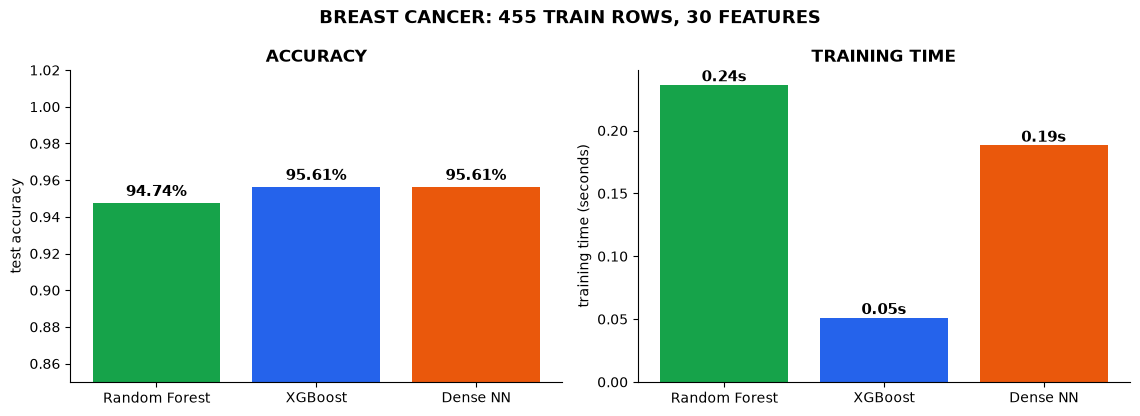

ตารางสรุป
  Random Forest    accuracy 94.74%   เวลา 0.24s
  XGBoost          accuracy 95.61%   เวลา 0.05s
  Dense NN         accuracy 95.61%   เวลา 0.19s


In [157]:
# ===== สรุปผล =====
names = list(scores)
accs = [scores[n][0] for n in names]
times = [scores[n][1] for n in names]
colors = ['#16a34a', '#2563eb', '#ea580c']

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

ax = axes[0]
bars = ax.bar(names, accs, color=colors)
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.004, f'{a:.2%}',
            ha='center', fontsize=11, weight='bold')
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('test accuracy')
ax.set_title('ACCURACY', fontsize=12, weight='bold')
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
bars = ax.bar(names, times, color=colors)
for b, t in zip(bars, times):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f'{t:.2f}s',
            ha='center', va='bottom', fontsize=11, weight='bold')
ax.set_ylabel('training time (seconds)')
ax.set_title('TRAINING TIME', fontsize=12, weight='bold')
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('BREAST CANCER: 455 TRAIN ROWS, 30 FEATURES', fontsize=13, weight='bold')
fig.tight_layout()
fig.savefig(IMG / 'out_4_comparison.png', dpi=150)
plt.show()

print('ตารางสรุป')
for n in names:
    a, t = scores[n]
    print(f'  {n:16s} accuracy {a:.2%}   เวลา {t:.2f}s')

**รูปที่ 28** สรุป

## สรุป

ตัวเลข accuracy ออกมาใกล้เคียงกันมาก ต่างกันแค่ไม่กี่ตัวอย่างที่ทายผิด
ในขณะที่ **การสร้าง Model NN มีความยากมากกว่า**

|                          | Random Forest / XGBoost     | Dense NN                                                             |
| ------------------------ | --------------------------- | -------------------------------------------------------------------- |
| ต้อง scale ข้อมูลไหม     | ไม่ต้อง                     | **ต้อง**                                                             |
| ค่าที่ต้องตั้งเอง        | `n_estimators`, `max_depth` | ชั้น, หน่วย, activation, lr, optimizer, epoch, dropout, weight decay |
| ค่า default ใช้ได้เลยไหม | ใช้ได้เลย ผลดีทันที         | ต้องลองหลายรอบ                                                       |
| ตีความผลได้ไหม           | ได้ มี feature importance   | ยาก เป็นกล่องดำ                                                      |
| ต้องใช้ GPU ไหม          | ไม่ต้อง                     | ช่วยได้เมื่อข้อมูลใหญ่                                               |
| ข้อมูลน้อยแล้วเป็นไง     | ทนทานต่อ noise (Robust)     | overfit ง่าย                                                         |

> ### สรุปผลจากการ ทดสอบ
>
> **บนข้อมูลตารางขนาดเล็กถึงกลาง tree-based มักชนะหรือเสมอ NN**
> และมีความง่ายในการออกแบบ Model มากกว่า ดังนั้น Dataset ที่เป็นตารางหรือขนาดเล็กถึงกลางใช้กับ Treebase จะเก่งกว่า NN เสมอ
>
> **แล้ว NN เหมาะกับกรณีไหน** NN ชนะในงานที่ข้อมูลที่มีความซับซ้อนเช่น หรือข้อมูลที่มาก
> คือภาพ เสียง ข้อความ และวิดีโอ เป็นต้นไปทั้งหมด
> อีกทั้ง dense layer จะเป็นพื้นฐานหรือ Head เพื่อนำมาเรียนรู้ความสัมพันธ์ของโครงสร้างของ Model ที่ Advance เช่น CNN และ Transformer

**การตัดสินใจ**

| ข้อมูลแบบไหน                      | ควรเริ่มด้วย                 |
| --------------------------------- | ---------------------------- |
| ตาราง แถวหลักพันถึงหลักหมื่น      | XGBoost หรือ Random Forest   |
| ตาราง แถวหลักล้าน feature เยอะมาก | ลอง NN เทียบกับ tree         |
| ภาพ                               | CNN หรือ Vision Transformer  |
| ข้อความ                           | Transformer                  |
| อนุกรมเวลา                        | ลองทั้ง tree และ NN เทียบกัน |

---


---

## Keras

```python
import keras
from keras import layers

model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(30,)),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
              loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=300, verbose=0)
loss, acc = model.evaluate(X_test_scaled, y_test)
```


---


In [158]:
# ===== ล้าง SGD =====
del model_nn, rf, xgb, optimizer, loss_fn
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('ช่วงที่ 4 จบ')

ช่วงที่ 4 จบ


---

<a id="hw"></a>

# การบ้าน Titanic End-to-End

Train บนข้อมูลที่ตัวเอง clean มา

**โจทย์ย่อ**

1. ใช้ข้อมูล Titanic ที่ clean แล้วจากคาบ data preparation
2. สร้าง baseline ด้วย Random Forest หรือ XGBoost
3. สร้าง Dense NN โดยเขียน `nn.Module` และ training loop 5 ขั้นเอง
4. เทียบผลทั้งสองแบบ แล้วเขียนสรุปว่าตัวไหนชนะและเพราะอะไร
5. Upload ลง github <Optional>

**ไฟล์ที่ต้องส่ง** `CE564_W06_Assignment_Titanic.ipynb` ในโฟลเดอร์เดียวกันนี้
โจทย์เต็ม เกณฑ์ให้คะแนน และช่องว่างให้เติมอยู่ในไฟล์นั้น
